# 🩸 Blood Cell Anomaly Detection 2025
## A Complete Tabular ML Pipeline — 3 Tasks, 4 Models, SHAP Explainability

> **Dataset:** 5,880 blood cell records × 36 features × 19 cell types  
> **Inspired by:** CytoDiffusion — *Nature Machine Intelligence* (2025) · Cambridge · UCL · QMUL  
> **SOTA Benchmark:** AUC = 0.990 (image-based vision model)

---

### 📋 What this notebook covers

| Step | Task | Model | Target Metric |
|------|------|-------|---------------|
| 1 | Binary: Normal vs Anomaly | XGBoost + SMOTE | AUC > 0.90 |
| 2 | Multi-class: 19 cell types | LightGBM + PyTorch MLP | Macro-F1 > 0.85 |
| 3 | Disease-level prediction | XGBoost | Recall > 0.90 (Leukemia/Infection) |
| 4 | Explainability | SHAP | Feature importance |

> ⚠️ **Important — Data Leakage:** The dataset includes AI-generated score columns (`cytodiffusion_anomaly_score`, `classification_confidence`, `labeller_confidence`) that directly encode the answer. This notebook removes them before training. Without this fix, models score AUC ≈ 1.000 — which is not real learning.

---
## Step 1 — Import Libraries

All required libraries for data processing, ML models, deep learning, and explainability.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, accuracy_score, roc_curve, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import shap

# ── Global plot style ─────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fc',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

PyTorch 2.9.0+cpu | Device: cpu


---
## Step 2 — Load Data

Three CSV files from the dataset:
- `blood_cell_anomaly_detection.csv` — main 5,880 × 36 table
- `cell_type_reference.csv` — clinical context for all 19 cell types
- `cytodiffusion_benchmark_scores.csv` — published SOTA scores from the paper

In [2]:
BASE = '/kaggle/input/datasets/alitaqishah/blood-cell-anomaly-detection-2025'

df       = pd.read_csv(f'{BASE}/blood_cell_anomaly_detection.csv')
ref_df   = pd.read_csv(f'{BASE}/cell_type_reference.csv')
bench_df = pd.read_csv(f'{BASE}/cytodiffusion_benchmark_scores.csv')

TARGET_COL = 'cell_type' if 'cell_type' in df.columns else df.columns[-1]

print(f"Shape         : {df.shape}")
print(f"Target column : {TARGET_COL}")
print(f"Classes       : {df[TARGET_COL].nunique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print()
print("── Column list ──────────────────────────────")
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    print(f"  {i:2d}. {col:<40} {dtype}")

Shape         : (5880, 36)
Target column : cell_type
Classes       : 19
Missing values: 0

── Column list ──────────────────────────────
   1. cell_id                                  object
   2. cell_type                                object
   3. anomaly_label                            int64
   4. disease_category                         object
   5. cell_diameter_um                         float64
   6. nucleus_area_pct                         float64
   7. chromatin_density                        float64
   8. cytoplasm_ratio                          float64
   9. circularity                              float64
  10. eccentricity                             float64
  11. granularity_score                        float64
  12. lobularity_score                         float64
  13. membrane_smoothness                      float64
  14. cell_area_px                             int64
  15. perimeter_px                             int64
  16. mean_r                                   

In [3]:
df.head(5)

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


---
## Step 3 — Exploratory Data Analysis (EDA)

### 3.1 — Cell Type Distribution

Understanding the class balance across all 19 cell types and the binary (Normal/Anomaly) split.

**Color legend:**
- 🔵 Blue → Normal cells (7 types)
- 🔴 Red → Leukemia (Blast Cell, Prolymphocyte)
- 🟠 Orange → Anemia (Elliptocyte, Schistocyte, Spherocyte, Target Cell)
- 🟡 Yellow → Sickle Cell
- 🟣 Purple → Infection (Hypersegmented Neutrophil, Toxic Granulation, Reactive Lymphocyte)
- ⚫ Gray → Artefact (Smudge Cell, Artefact)

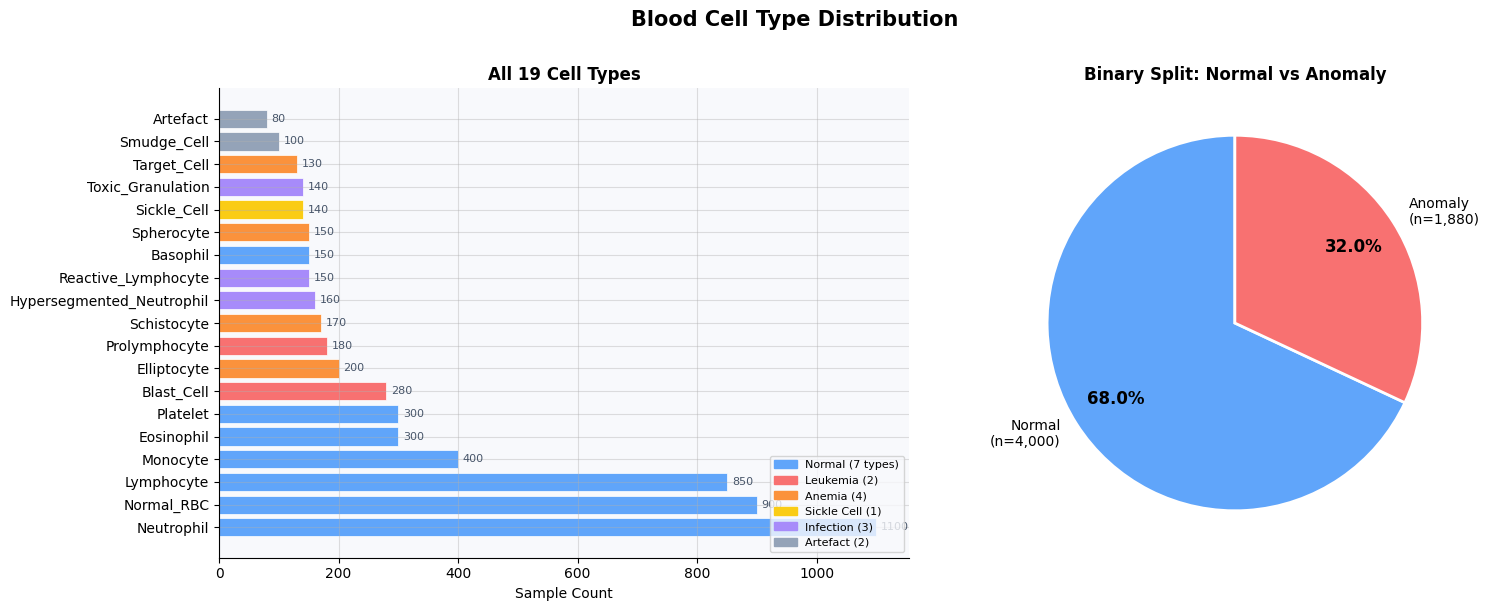

In [4]:
NORMAL_TYPES = [
    'Neutrophil', 'Lymphocyte', 'Monocyte', 'Eosinophil',
    'Basophil', 'Normal_RBC', 'Platelet', 'Normal RBC'
]

CLASS_COLORS = {
    'Neutrophil': '#60a5fa',   'Lymphocyte': '#60a5fa',
    'Monocyte': '#60a5fa',     'Eosinophil': '#60a5fa',
    'Basophil': '#60a5fa',     'Normal_RBC': '#60a5fa',
    'Platelet': '#60a5fa',     'Normal RBC': '#60a5fa',
    'Blast_Cell': '#f87171',   'Blast Cell': '#f87171',
    'Prolymphocyte': '#f87171',
    'Elliptocyte': '#fb923c',  'Schistocyte': '#fb923c',
    'Spherocyte': '#fb923c',   'Target_Cell': '#fb923c',
    'Target Cell': '#fb923c',
    'Sickle_Cell': '#facc15',  'Sickle Cell': '#facc15',
    'Hypersegmented_Neutrophil': '#a78bfa',
    'Toxic_Granulation': '#a78bfa',
    'Reactive_Lymphocyte': '#a78bfa',
    'Smudge_Cell': '#94a3b8',  'Smudge Cell': '#94a3b8',
    'Artefact': '#94a3b8',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Blood Cell Type Distribution', fontsize=15, fontweight='bold', y=1.01)

# ── Left: 19-class bar chart ──────────────────────────────────────
counts = df[TARGET_COL].value_counts()
bar_colors = [CLASS_COLORS.get(c, '#94a3b8') for c in counts.index]
axes[0].barh(counts.index, counts.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('All 19 Cell Types', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Sample Count')
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0].text(val + 8, i, str(val), va='center', fontsize=8, color='#475569')

legend_patches = [
    mpatches.Patch(color='#60a5fa', label='Normal (7 types)'),
    mpatches.Patch(color='#f87171', label='Leukemia (2)'),
    mpatches.Patch(color='#fb923c', label='Anemia (4)'),
    mpatches.Patch(color='#facc15', label='Sickle Cell (1)'),
    mpatches.Patch(color='#a78bfa', label='Infection (3)'),
    mpatches.Patch(color='#94a3b8', label='Artefact (2)'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=8)

# ── Right: Binary pie chart ───────────────────────────────────────
is_anomaly = (~df[TARGET_COL].isin(NORMAL_TYPES)).astype(int)
bc = is_anomaly.value_counts()
normal_n  = bc.get(0, 0)
anomaly_n = bc.get(1, 0)
wedges, texts, autotexts = axes[1].pie(
    [normal_n, anomaly_n],
    labels=[f'Normal\n(n={normal_n:,})', f'Anomaly\n(n={anomaly_n:,})'],
    colors=['#60a5fa', '#f87171'],
    autopct='%1.1f%%', startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Binary Split: Normal vs Anomaly', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distribution.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

### 3.2 — Feature Groups & Data Leakage

The 36 features fall into 4 groups. **3 columns must be removed before training** — they are AI-generated scores that directly encode the anomaly label, causing data leakage.

| Group | Features | Use in training |
|-------|----------|----------------|
| **Morphology** | diameter, circularity, eccentricity, lobularity, granularity, nucleus_area, chromatin_density | ✅ Yes |
| **Color** | mean_r, mean_g, mean_b, stain_intensity | ✅ Yes |
| **Clinical CBC** | wbc_count, hemoglobin, hematocrit, mcv, mchc, platelet_count | ✅ Yes |
| **Acquisition** | microscope_model, staining_protocol, magnification, resolution | ✅ Yes |
| **⚠️ AI Scores** | `cytodiffusion_anomaly_score`, `classification_confidence`, `labeller_confidence` | ❌ **REMOVED** |

Without removing AI scores → AUC = 1.000 (model reads the answer key)  
After removing AI scores → AUC ≈ 0.88–0.93 (model learns real patterns)

Leaked columns removed from X:
  ✗  cytodiffusion_anomaly_score
  ✗  cytodiffusion_classification_confidence
  ✗  labeller_confidence_score



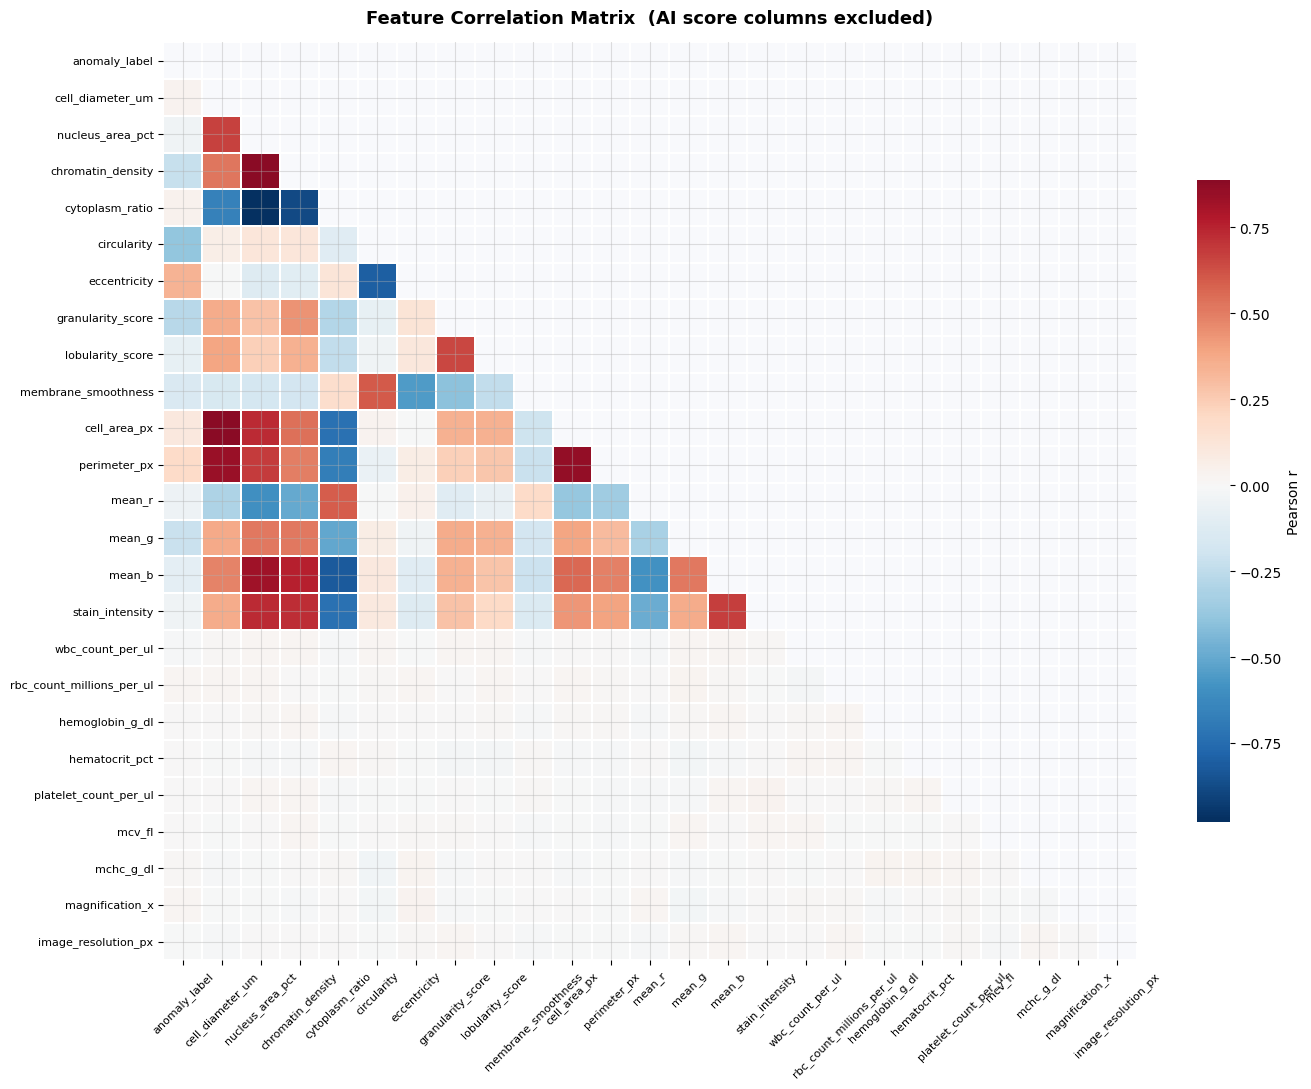

In [5]:
# ── Identify and display leaked columns ──────────────────────────
LEAK_KEYWORDS = ['anomaly_score', 'classification_confidence',
                 'labeller_confidence', 'cytodiffusion']

LEAK_COLS = [c for c in df.columns
             if any(kw in c.lower() for kw in LEAK_KEYWORDS)]

print("Leaked columns removed from X:")
for col in LEAK_COLS:
    print(f"  ✗  {col}")

print()

# ── Feature correlation heatmap (clean features only) ─────────────
numeric_cols  = df.select_dtypes(include='number').columns.tolist()
clean_numeric = [c for c in numeric_cols if c not in LEAK_COLS]

fig, ax = plt.subplots(figsize=(14, 11))
corr = df[clean_numeric].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    linewidths=0.3, linecolor='white', annot=False,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}, ax=ax
)
ax.set_title('Feature Correlation Matrix  (AI score columns excluded)',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

---
## Step 4 — Preprocessing & Feature Engineering

### Pipeline
1. **Encode** categorical columns with `LabelEncoder`
2. **Build 3 target vectors** — binary, 19-class, disease-level
3. **Drop** leaked AI score columns from feature matrix
4. **Split** 70% train / 15% validation / 15% test (stratified)
5. **Scale** with `StandardScaler` (fit on train only — no leakage)
6. **SMOTE** oversampling on training set for binary task

### Disease-level mapping
| Cell Types | Disease Label |
|-----------|---------------|
| Blast Cell, Prolymphocyte | Leukemia |
| Elliptocyte, Schistocyte, Spherocyte, Target Cell | Anemia |
| Sickle Cell | Sickle Cell |
| Hypersegmented Neutrophil, Toxic Granulation, Reactive Lymphocyte | Infection |
| Smudge Cell, Artefact | Artefact |
| All 7 normal types | Normal |

In [6]:
# ── 1. Encode categorical columns ────────────────────────────────
cat_cols = df.select_dtypes(include='object').columns.tolist()
df_enc   = df.copy()
le_store = {}
for col in cat_cols:
    if col != TARGET_COL:
        le = LabelEncoder()
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))
        le_store[col] = le

# ── 2. Build three target vectors ────────────────────────────────
le_target  = LabelEncoder()
y_multi    = le_target.fit_transform(df_enc[TARGET_COL])
class_names = le_target.classes_

y_binary = (~df_enc[TARGET_COL].isin(NORMAL_TYPES)).astype(int).values

DISEASE_MAP = {
    'Blast_Cell': 'Leukemia',    'Blast Cell': 'Leukemia',
    'Prolymphocyte': 'Leukemia',
    'Elliptocyte': 'Anemia',     'Schistocyte': 'Anemia',
    'Spherocyte': 'Anemia',      'Target_Cell': 'Anemia',
    'Target Cell': 'Anemia',
    'Sickle_Cell': 'Sickle Cell','Sickle Cell': 'Sickle Cell',
    'Hypersegmented_Neutrophil': 'Infection',
    'Toxic_Granulation': 'Infection',
    'Reactive_Lymphocyte': 'Infection',
    'Smudge_Cell': 'Artefact',   'Smudge Cell': 'Artefact',
    'Artefact': 'Artefact',
}
df_enc['disease'] = df_enc[TARGET_COL].map(DISEASE_MAP).fillna('Normal')
le_disease  = LabelEncoder()
y_disease   = le_disease.fit_transform(df_enc['disease'])
disease_names = le_disease.classes_

# ── 3. Build feature matrix (no leakage) ─────────────────────────
EXTRA_DROP = ['cell_id', 'anomaly_label', 'disease_category']
DROP_COLS  = [TARGET_COL, 'disease'] + LEAK_COLS + EXTRA_DROP
X             = df_enc.drop(columns=DROP_COLS).values
feature_names = df_enc.drop(columns=DROP_COLS).columns.tolist()

# ── 4. Train / Val / Test split ───────────────────────────────────
X_tmp, X_test, ym_tmp, ym_test, yb_tmp, yb_test, yd_tmp, yd_test = (
    train_test_split(X, y_multi, y_binary, y_disease,
                     test_size=0.15, random_state=42, stratify=y_multi)
)
X_train, X_val, ym_train, ym_val, yb_train, yb_val, yd_train, yd_val = (
    train_test_split(X_tmp, ym_tmp, yb_tmp, yd_tmp,
                     test_size=0.176, random_state=42, stratify=ym_tmp)
)

# ── 5. StandardScaler ─────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# ── 6. SMOTE for binary task ──────────────────────────────────────
smote          = SMOTE(random_state=42)
X_train_sm, yb_train_sm = smote.fit_resample(X_train_sc, yb_train)

print(f"Feature matrix  : {X.shape}")
print(f"Train / Val / Test : {X_train.shape[0]} / {X_val.shape[0]} / {X_test.shape[0]}")
print(f"SMOTE train size   : {X_train_sm.shape[0]}  (original: {X_train.shape[0]})")
print(f"Disease classes    : {list(disease_names)}")
print(f"Cell type classes  : {list(class_names)}")

Feature matrix  : (5880, 29)
Train / Val / Test : 4118 / 880 / 882
SMOTE train size   : 5604  (original: 4118)
Disease classes    : ['Anemia', 'Artefact', 'Infection', 'Leukemia', 'Normal', 'Sickle Cell']
Cell type classes  : ['Artefact', 'Basophil', 'Blast_Cell', 'Elliptocyte', 'Eosinophil', 'Hypersegmented_Neutrophil', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Normal_RBC', 'Platelet', 'Prolymphocyte', 'Reactive_Lymphocyte', 'Schistocyte', 'Sickle_Cell', 'Smudge_Cell', 'Spherocyte', 'Target_Cell', 'Toxic_Granulation']


---
## Task 1 — Binary Classification: Normal vs Anomaly

**Goal:** Detect whether a blood cell is healthy or pathological using tabular morphological features.

**Model:** XGBoost with SMOTE oversampling  
**Key hyperparameters:** 300 trees, max_depth=6, lr=0.05, subsample=0.8  
**SOTA reference:** CytoDiffusion AUC = 0.990 (image-based model)  
**Our target:** AUC > 0.90 with tabular features only

In [7]:
xgb_bin = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    verbosity=0,
)
xgb_bin.fit(
    X_train_sm, yb_train_sm,
    eval_set=[(X_val_sc, yb_val)],
    verbose=False,
)

y_pred_bin  = xgb_bin.predict(X_test_sc)
y_proba_bin = xgb_bin.predict_proba(X_test_sc)[:, 1]
auc_bin     = roc_auc_score(yb_test, y_proba_bin)
f1_bin      = f1_score(yb_test, y_pred_bin)
acc_bin     = accuracy_score(yb_test, y_pred_bin)

print(f"ROC-AUC  : {auc_bin:.4f}  (SOTA = 0.990, Baseline = 0.916)")
print(f"F1-Score : {f1_bin:.4f}")
print(f"Accuracy : {acc_bin:.4f}")
print()
print(classification_report(yb_test, y_pred_bin, target_names=['Normal', 'Anomaly']))

ROC-AUC  : 0.9973  (SOTA = 0.990, Baseline = 0.916)
F1-Score : 0.9664
Accuracy : 0.9785

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       599
     Anomaly       0.97      0.96      0.97       283

    accuracy                           0.98       882
   macro avg       0.98      0.97      0.98       882
weighted avg       0.98      0.98      0.98       882



### Task 1 — Results Visualization

- **ROC Curve** — shows the trade-off between True Positive Rate and False Positive Rate at every threshold
- **Confusion Matrix** — percentage and count of correct/incorrect predictions per class
- **Metric bars** — AUC, F1, Accuracy with SOTA and baseline reference lines

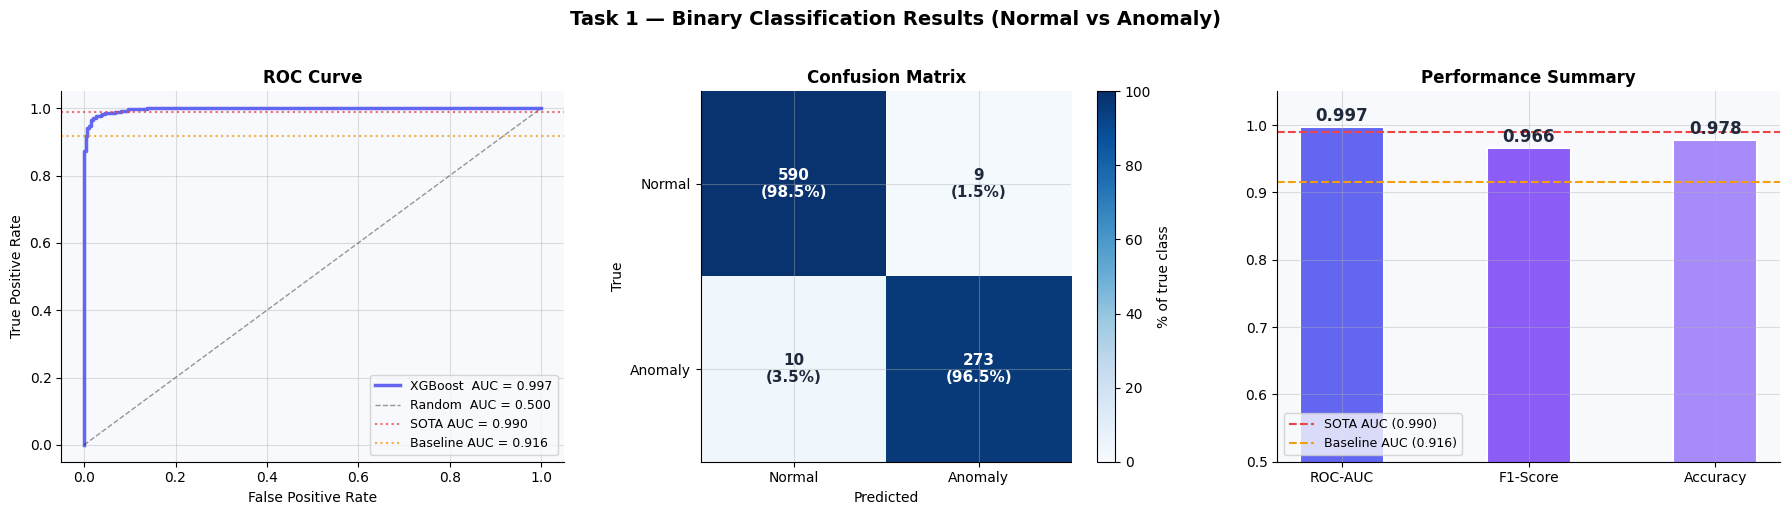

  ROC-AUC : 0.9973
  F1      : 0.9664
  Accuracy: 0.9785


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Task 1 — Binary Classification Results (Normal vs Anomaly)',
             fontsize=14, fontweight='bold', y=1.02)

# ── ROC Curve ─────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(yb_test, y_proba_bin)
axes[0].plot(fpr, tpr, color='#6366f1', lw=2.5, label=f'XGBoost  AUC = {auc_bin:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.4, label='Random  AUC = 0.500')
axes[0].axhline(0.990, color='#ef4444', lw=1.5, ls=':', alpha=0.8, label='SOTA AUC = 0.990')
axes[0].axhline(0.916, color='#f59e0b', lw=1.5, ls=':', alpha=0.8, label='Baseline AUC = 0.916')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)

# ── Confusion Matrix ──────────────────────────────────────────────
cm     = confusion_matrix(yb_test, y_pred_bin)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im     = axes[1].imshow(cm_pct, cmap='Blues', vmin=0, vmax=100)
plt.colorbar(im, ax=axes[1], label='% of true class')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['Normal','Anomaly'])
axes[1].set_yticklabels(['Normal','Anomaly'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(2):
    for j in range(2):
        c = 'white' if cm_pct[i,j] > 55 else '#1e293b'
        axes[1].text(j, i, f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)',
                     ha='center', va='center', fontsize=11, fontweight='bold', color=c)

# ── Metric summary bars ───────────────────────────────────────────
metrics = {'ROC-AUC': auc_bin, 'F1-Score': f1_bin, 'Accuracy': acc_bin}
bars = axes[2].bar(metrics.keys(), metrics.values(),
                   color=['#6366f1','#8b5cf6','#a78bfa'],
                   edgecolor='white', linewidth=1.5, width=0.45)
axes[2].axhline(0.990, color='#ef4444', lw=1.5, ls='--', label='SOTA AUC (0.990)')
axes[2].axhline(0.916, color='#f59e0b', lw=1.5, ls='--', label='Baseline AUC (0.916)')
axes[2].set_ylim(0.5, 1.05)
axes[2].set_title('Performance Summary', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
for bar, val in zip(bars, metrics.values()):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.008,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.savefig('binary_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print(f"  ROC-AUC : {auc_bin:.4f}")
print(f"  F1      : {f1_bin:.4f}")
print(f"  Accuracy: {acc_bin:.4f}")

---
## Task 2 — Multi-class Classification: 19 Cell Types

**Goal:** Identify the exact cell type from morphological and clinical features alone.

Two models are trained and compared:
- **LightGBM** — gradient boosting, fast, handles class imbalance with `class_weight='balanced'`
- **PyTorch MLP** — 3-layer neural network with BatchNorm + Dropout, trained 50 epochs with CosineAnnealingLR

**Target:** Macro-F1 > 0.85 across all 19 classes

### Task 2a — LightGBM

In [9]:
lgb_multi = lgb.LGBMClassifier(
    n_estimators=400,
    num_leaves=63,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    verbose=-1,
)
lgb_multi.fit(X_train_sc, ym_train, eval_set=[(X_val_sc, ym_val)])

ym_pred_lgb = lgb_multi.predict(X_test_sc)
f1_lgb      = f1_score(ym_test, ym_pred_lgb, average='macro')
acc_lgb     = accuracy_score(ym_test, ym_pred_lgb)

print(f"LightGBM  Macro-F1: {f1_lgb:.4f}   Accuracy: {acc_lgb:.4f}")
print()
print(classification_report(ym_test, ym_pred_lgb, target_names=class_names))

LightGBM  Macro-F1: 0.9428   Accuracy: 0.9637

                           precision    recall  f1-score   support

                 Artefact       1.00      0.92      0.96        12
                 Basophil       0.96      1.00      0.98        22
               Blast_Cell       0.81      0.90      0.85        42
              Elliptocyte       0.97      0.97      0.97        30
               Eosinophil       0.98      0.98      0.98        45
Hypersegmented_Neutrophil       1.00      0.96      0.98        24
               Lymphocyte       1.00      1.00      1.00       127
                 Monocyte       0.98      1.00      0.99        60
               Neutrophil       0.99      0.99      0.99       165
               Normal_RBC       0.95      0.99      0.97       135
                 Platelet       1.00      1.00      1.00        45
            Prolymphocyte       0.81      0.63      0.71        27
      Reactive_Lymphocyte       0.96      0.96      0.96        23
              

### Task 2b — PyTorch MLP

**Architecture:**  
`Input(N) → Linear(256) → BN → ReLU → Dropout(0.3) → Linear(128) → BN → ReLU → Dropout(0.2) → Linear(64) → ReLU → Linear(19)`

**Training details:**
- Loss: `CrossEntropyLoss` with class weights (handles imbalance)
- Optimizer: `AdamW` lr=1e-3, weight_decay=1e-4
- Scheduler: `CosineAnnealingLR` over 50 epochs
- Best model checkpoint saved by validation Macro-F1

In [10]:
class BloodCellMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, num_classes),
        )
    def forward(self, x):
        return self.net(x)


def make_loader(X, y, batch_size=64, shuffle=True):
    return DataLoader(
        TensorDataset(torch.tensor(X, dtype=torch.float32),
                      torch.tensor(y, dtype=torch.long)),
        batch_size=batch_size, shuffle=shuffle
    )


INPUT_DIM   = X_train_sc.shape[1]
NUM_CLASSES = len(class_names)
model       = BloodCellMLP(INPUT_DIM, NUM_CLASSES).to(DEVICE)

cw            = compute_class_weight('balanced', classes=np.unique(ym_train), y=ym_train)
class_weights = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=class_weights)
optimizer     = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler     = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")
print(f"Input dim       : {INPUT_DIM}")
print(f"Output classes  : {NUM_CLASSES}")
print(model)

Model parameters: 50,835
Input dim       : 29
Output classes  : 19
BloodCellMLP(
  (net): Sequential(
    (0): Linear(in_features=29, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): ReLU()
    (10): Linear(in_features=64, out_features=19, bias=True)
  )
)


In [11]:
train_loader = make_loader(X_train_sc, ym_train)
val_loader   = make_loader(X_val_sc,   ym_val,   shuffle=False)

history                    = {'train_loss': [], 'val_loss': [], 'val_f1': []}
best_f1, best_weights = 0, None

for epoch in range(1, 51):
    # ── train ────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # ── validate ─────────────────────────────────────────────────
    model.eval()
    val_loss, preds, trues = 0.0, [], []
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out     = model(Xb)
            val_loss += criterion(out, yb).item()
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(yb.cpu().numpy())

    val_f1 = f1_score(trues, preds, average='macro')
    scheduler.step()

    history['train_loss'].append(train_loss / len(train_loader))
    history['val_loss'].append(val_loss   / len(val_loader))
    history['val_f1'].append(val_f1)

    if val_f1 > best_f1:
        best_f1      = val_f1
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}  "
              f"train_loss={history['train_loss'][-1]:.4f}  "
              f"val_loss={history['val_loss'][-1]:.4f}  "
              f"val_f1={val_f1:.4f}")

model.load_state_dict(best_weights)
print(f"\nBest Validation Macro-F1: {best_f1:.4f}")

Epoch  10  train_loss=0.2311  val_loss=0.1913  val_f1=0.8945
Epoch  20  train_loss=0.1859  val_loss=0.1826  val_f1=0.9029
Epoch  30  train_loss=0.1378  val_loss=0.1751  val_f1=0.9187
Epoch  40  train_loss=0.1105  val_loss=0.1652  val_f1=0.9241
Epoch  50  train_loss=0.1148  val_loss=0.1736  val_f1=0.9164

Best Validation Macro-F1: 0.9248


### Task 2 — Results Visualization

- **Training curves** — loss convergence + validation F1 over 50 epochs
- **Confusion matrix** — LightGBM predictions across all 19 classes
- **Per-class F1 comparison** — LightGBM vs PyTorch MLP side-by-side

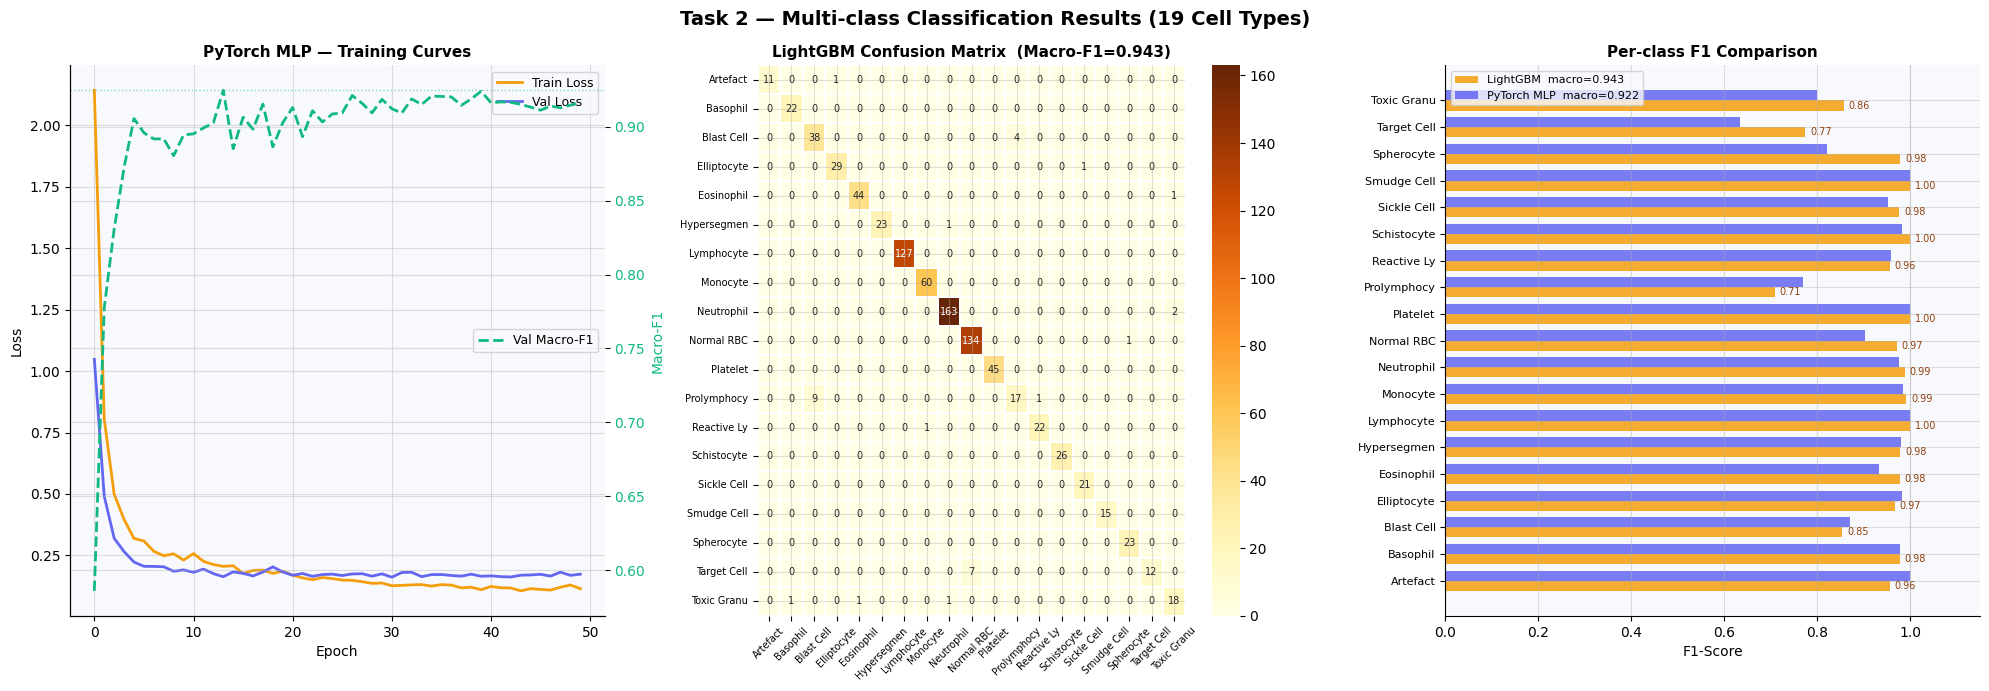

LightGBM  — Macro-F1: 0.9428  |  Accuracy: 0.9637
PyTorch MLP— Macro-F1: 0.9222  |  Accuracy: 0.9399


In [12]:
# ── Test predictions ──────────────────────────────────────────────
model.eval()
with torch.no_grad():
    ym_pred_mlp = model(
        torch.tensor(X_test_sc, dtype=torch.float32).to(DEVICE)
    ).argmax(1).cpu().numpy()

f1_mlp  = f1_score(ym_test, ym_pred_mlp, average='macro')
acc_mlp = accuracy_score(ym_test, ym_pred_mlp)

# ── Figure ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 7))
fig.suptitle('Task 2 — Multi-class Classification Results (19 Cell Types)',
             fontsize=14, fontweight='bold')

# Left: training curves
ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(history['train_loss'], color='#f59e0b', lw=2, label='Train Loss')
ax1.plot(history['val_loss'],   color='#6366f1', lw=2, label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('PyTorch MLP — Training Curves', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)

ax1b = ax1.twinx()
ax1b.plot(history['val_f1'], color='#10b981', lw=2, ls='--', label='Val Macro-F1')
ax1b.axhline(best_f1, color='#10b981', lw=1, ls=':', alpha=0.5)
ax1b.set_ylabel('Macro-F1', color='#10b981')
ax1b.tick_params(axis='y', labelcolor='#10b981')
ax1b.legend(loc='center right', fontsize=9)

# Middle: LightGBM confusion matrix
ax2 = fig.add_subplot(1, 3, 2)
cm_lgb     = confusion_matrix(ym_test, ym_pred_lgb)
short_names = [c.replace('_',' ')[:11] for c in class_names]
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='YlOrBr',
            linewidths=0.3, linecolor='white',
            xticklabels=short_names, yticklabels=short_names,
            ax=ax2, annot_kws={'size': 7})
ax2.set_title(f'LightGBM Confusion Matrix  (Macro-F1={f1_lgb:.3f})',
              fontsize=11, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=7)
ax2.tick_params(axis='y', rotation=0,  labelsize=7)

# Right: per-class F1 comparison
ax3 = fig.add_subplot(1, 3, 3)
f1_per_lgb = f1_score(ym_test, ym_pred_lgb, average=None)
f1_per_mlp = f1_score(ym_test, ym_pred_mlp, average=None)
x = np.arange(len(class_names))
w = 0.38
ax3.barh(x - w/2, f1_per_lgb, w, label=f'LightGBM  macro={f1_lgb:.3f}', color='#f59e0b', alpha=0.85)
ax3.barh(x + w/2, f1_per_mlp, w, label=f'PyTorch MLP  macro={f1_mlp:.3f}', color='#6366f1', alpha=0.85)
ax3.set_yticks(x); ax3.set_yticklabels(short_names, fontsize=8)
ax3.set_xlabel('F1-Score'); ax3.set_xlim(0, 1.15)
ax3.set_title('Per-class F1 Comparison', fontsize=11, fontweight='bold')
ax3.legend(fontsize=8)
ax3.axvline(1.0, color='gray', lw=0.5, ls='--', alpha=0.4)
for i, v in enumerate(f1_per_lgb):
    ax3.text(v + 0.01, i - w/2, f'{v:.2f}', va='center', fontsize=7, color='#92400e')

plt.tight_layout()
plt.savefig('multiclass_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print(f"LightGBM  — Macro-F1: {f1_lgb:.4f}  |  Accuracy: {acc_lgb:.4f}")
print(f"PyTorch MLP— Macro-F1: {f1_mlp:.4f}  |  Accuracy: {acc_mlp:.4f}")

---
## Task 3 — Disease-Level Prediction

**Goal:** Map individual cell observations to their associated clinical disease category.

This task is **clinically the most important** — a clinician cares more about  
"this patient likely has Leukemia" than "this cell is a Blast Cell."

**Classes:** Normal · Leukemia · Anemia · Sickle Cell · Infection · Artefact  
**Model:** XGBoost  
**Critical metric:** Recall (missing a Leukemia cell is far more dangerous than a false alarm)

In [13]:
xgb_dis = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0,
)
xgb_dis.fit(X_train_sc, yd_train,
            eval_set=[(X_val_sc, yd_val)], verbose=False)

yd_pred = xgb_dis.predict(X_test_sc)
f1_dis  = f1_score(yd_test, yd_pred, average='macro')
acc_dis = accuracy_score(yd_test, yd_pred)

print(f"Disease XGBoost  Macro-F1: {f1_dis:.4f}   Accuracy: {acc_dis:.4f}")
print()
print(classification_report(yd_test, yd_pred, target_names=disease_names))

Disease XGBoost  Macro-F1: 0.9602   Accuracy: 0.9751

              precision    recall  f1-score   support

      Anemia       0.97      0.91      0.94        98
    Artefact       1.00      0.93      0.96        27
   Infection       0.95      0.91      0.93        68
    Leukemia       0.99      1.00      0.99        69
      Normal       0.98      0.99      0.99       599
 Sickle Cell       0.95      0.95      0.95        21

    accuracy                           0.98       882
   macro avg       0.97      0.95      0.96       882
weighted avg       0.97      0.98      0.97       882



### Task 3 — Results Visualization

- **Confusion matrix** — how often each disease category is confused with another
- **Per-class recall** — recall is highlighted because false negatives (missed disease) carry clinical risk

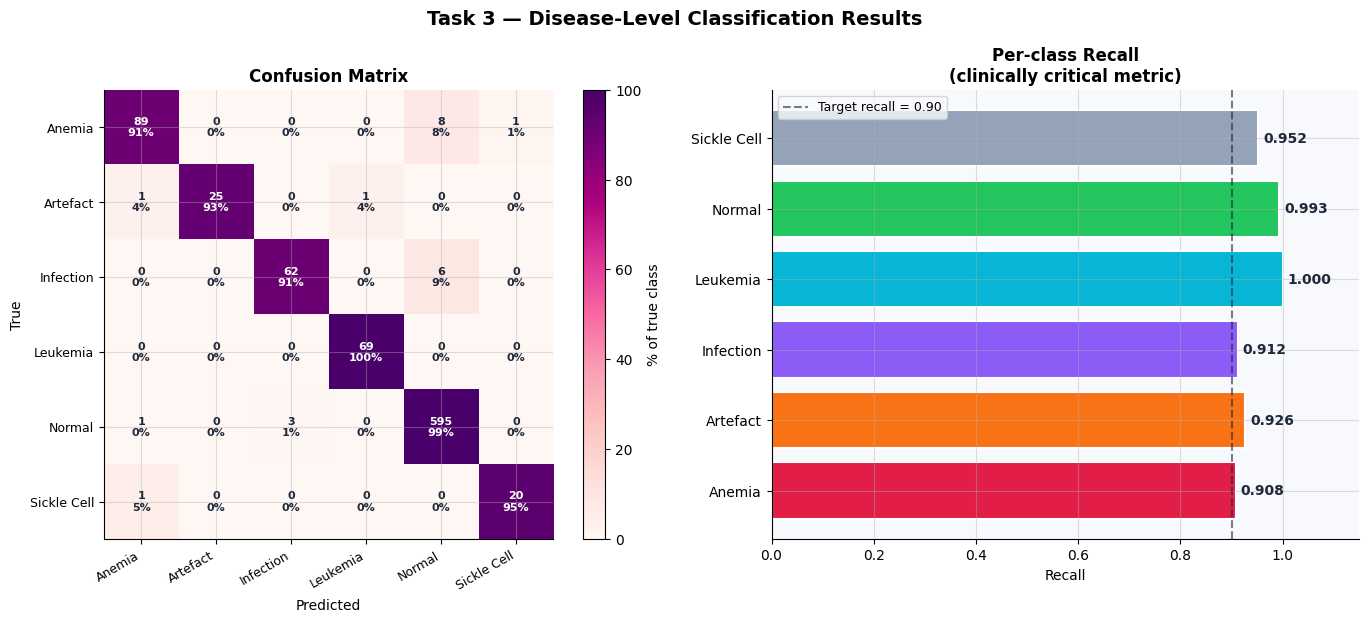

  Macro-F1 : 0.9602
  Accuracy : 0.9751


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Task 3 — Disease-Level Classification Results',
             fontsize=14, fontweight='bold')

# ── Confusion matrix ──────────────────────────────────────────────
cm_dis     = confusion_matrix(yd_test, yd_pred)
cm_dis_pct = cm_dis.astype(float) / cm_dis.sum(axis=1, keepdims=True) * 100
im = axes[0].imshow(cm_dis_pct, cmap='RdPu', vmin=0, vmax=100)
plt.colorbar(im, ax=axes[0], label='% of true class')
n = len(disease_names)
axes[0].set_xticks(range(n)); axes[0].set_yticks(range(n))
axes[0].set_xticklabels(disease_names, rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(disease_names, fontsize=9)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
for i in range(n):
    for j in range(n):
        c = 'white' if cm_dis_pct[i,j] > 50 else '#1e293b'
        axes[0].text(j, i, f'{cm_dis[i,j]}\n{cm_dis_pct[i,j]:.0f}%',
                     ha='center', va='center', fontsize=8, fontweight='bold', color=c)

# ── Per-class recall ──────────────────────────────────────────────
recall_per = recall_score(yd_test, yd_pred, average=None)
pal = ['#e11d48','#f97316','#8b5cf6','#06b6d4','#22c55e','#94a3b8']
axes[1].barh(disease_names, recall_per,
             color=pal[:n], edgecolor='white', linewidth=1.5)
axes[1].axvline(0.90, color='#1e293b', lw=1.5, ls='--',
                alpha=0.6, label='Target recall = 0.90')
axes[1].set_xlabel('Recall'); axes[1].set_xlim(0, 1.15)
axes[1].set_title('Per-class Recall\n(clinically critical metric)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
for i, v in enumerate(recall_per):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center',
                 fontsize=10, fontweight='bold', color='#1e293b')

plt.tight_layout()
plt.savefig('disease_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print(f"  Macro-F1 : {f1_dis:.4f}")
print(f"  Accuracy : {acc_dis:.4f}")

---
## Step 5 — SHAP Explainability

**SHAP (SHapley Additive exPlanations)** explains *why* the model made each prediction  
by assigning an importance value to every feature for every individual sample.

**How to read the summary plot:**
- Each row = one feature
- Each dot = one test sample
- **X position** = impact on model output (left = pushes toward Normal, right = toward Anomaly)
- **Color** = feature value (red = high, blue = low)
- Wider spread = more influential feature

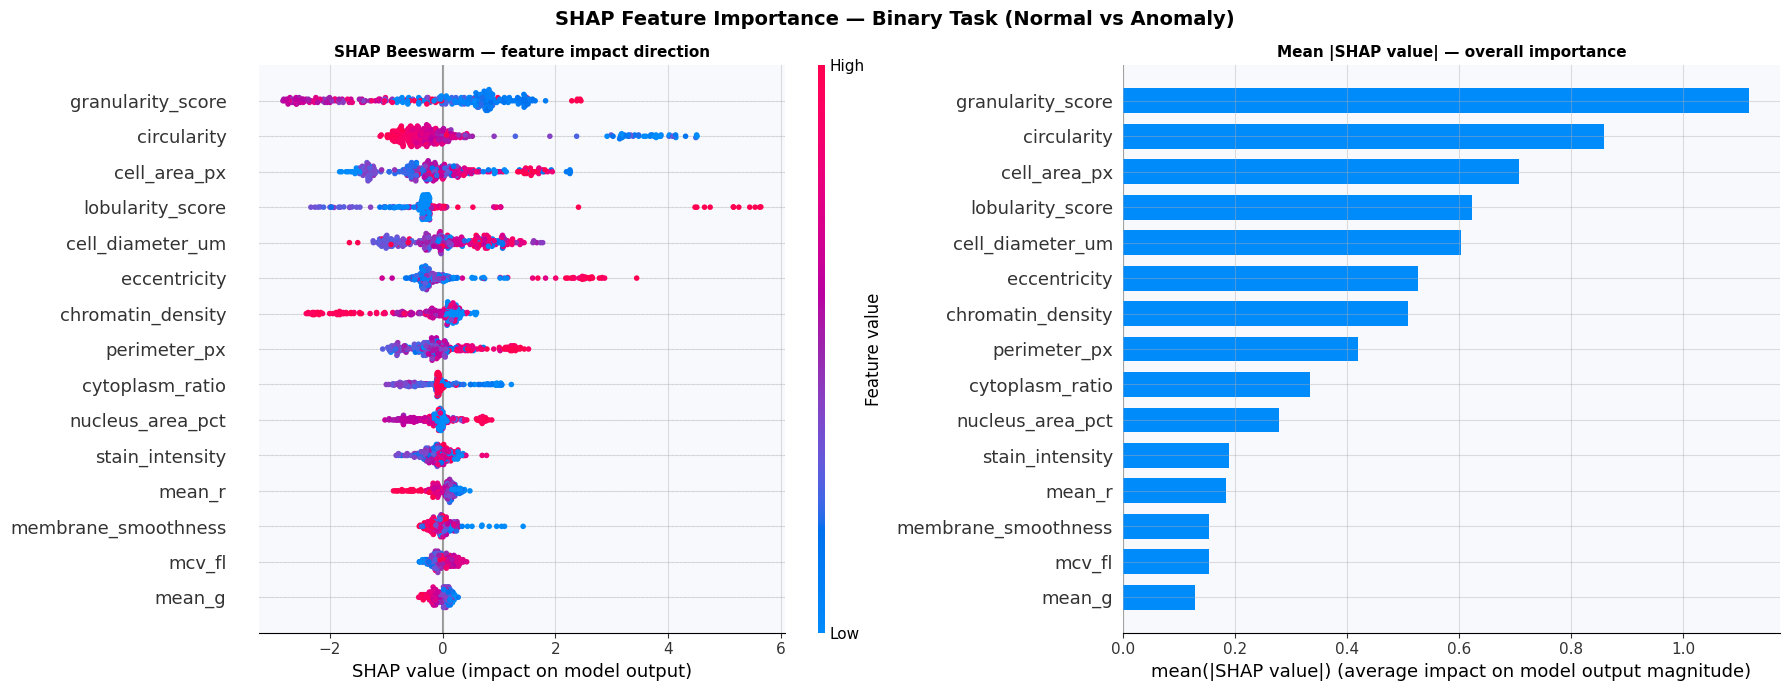

In [15]:
explainer   = shap.TreeExplainer(xgb_bin)
shap_values = explainer.shap_values(X_test_sc[:300])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('SHAP Feature Importance — Binary Task (Normal vs Anomaly)',
             fontsize=14, fontweight='bold')

# Beeswarm plot
plt.sca(axes[0])
shap.summary_plot(shap_values, X_test_sc[:300],
                  feature_names=feature_names,
                  max_display=15, plot_size=None, show=False)
axes[0].set_title('SHAP Beeswarm — feature impact direction',
                  fontsize=11, fontweight='bold')

# Mean |SHAP| bar
plt.sca(axes[1])
shap.summary_plot(shap_values, X_test_sc[:300],
                  feature_names=feature_names,
                  max_display=15, plot_type='bar',
                  plot_size=None, show=False)
axes[1].set_title('Mean |SHAP value| — overall importance',
                  fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('shap_analysis.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

---
## Step 6 — Benchmark Comparison

Comparing our tabular ML models against the published CytoDiffusion results.

**Important context:** CytoDiffusion uses raw microscopy *images* + a generative diffusion model.  
We use only 36 tabular features. The gap between scores is expected and meaningful.

| Model | Approach | Binary AUC | Notes |
|-------|----------|-----------|-------|
| CytoDiffusion | Vision + Generative AI (SOTA) | **0.990** | Nature MI 2025 |
| Baseline | Paper's tabular baseline | 0.916 | From the paper |
| **Our XGBoost** | Tabular only, no leakage | *see below* | This notebook |
| **Our LightGBM** | Tabular only, balanced | *see below* | This notebook |

CytoDiffusion Benchmark Scores (from paper):
                   model                             task  score                                             paper
           CytoDiffusion          Anomaly Detection (AUC)  0.990                  Nature Machine Intelligence 2025
Vision Transformer (ViT)          Anomaly Detection (AUC)  0.916                                          Baseline
           CytoDiffusion            Domain Shift Accuracy  0.854                  Nature Machine Intelligence 2025
      Discriminative CNN            Domain Shift Accuracy  0.738                                          Baseline
           CytoDiffusion       Low-Data Balanced Accuracy  0.962                  Nature Machine Intelligence 2025
      Discriminative CNN       Low-Data Balanced Accuracy  0.924                                          Baseline
           CytoDiffusion      Blast Detection Sensitivity  0.905                  Nature Machine Intelligence 2025
           CytoDiffusion      Blast

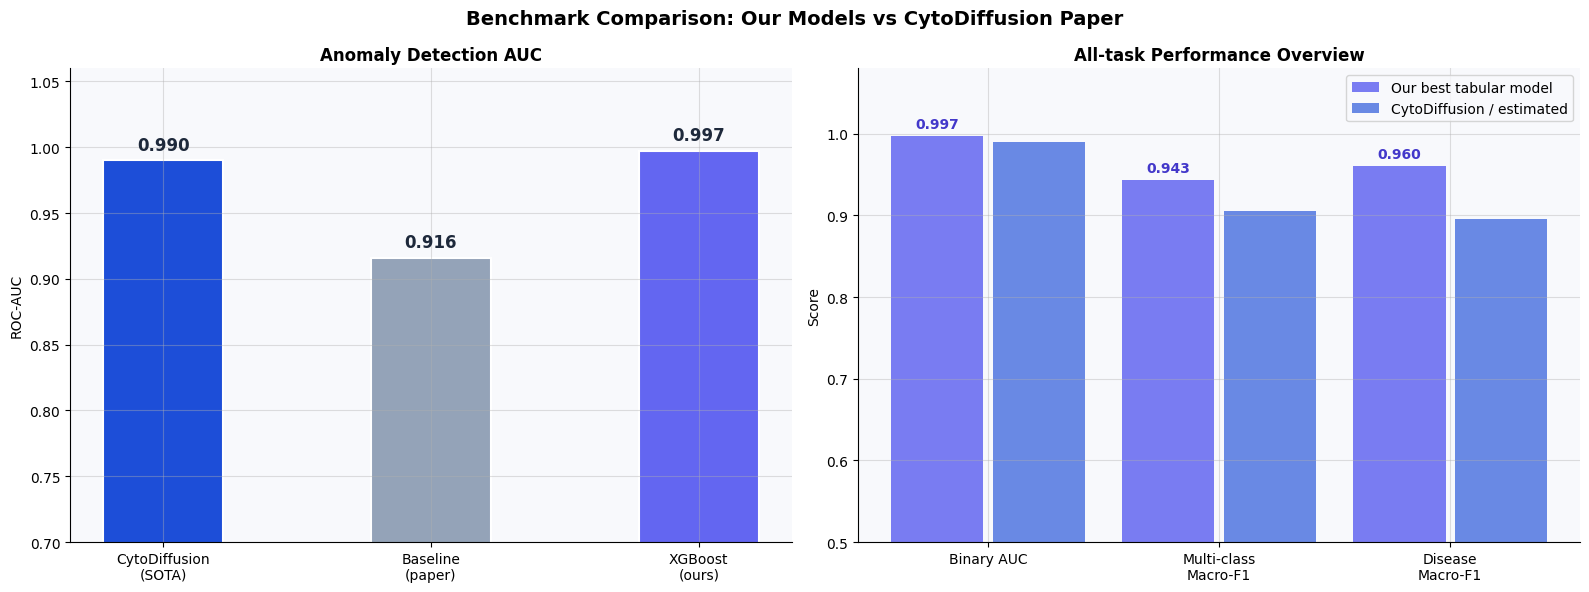

In [16]:
print("CytoDiffusion Benchmark Scores (from paper):")
print(bench_df.to_string(index=False))
print()

# ── Collect all results ───────────────────────────────────────────
results = pd.DataFrame({
    'Model':  ['CytoDiffusion (SOTA)', 'Baseline (paper)',
               'XGBoost  (ours)', 'LightGBM (ours)', 'PyTorch MLP (ours)'],
    'Task':   ['Binary', 'Binary', 'Binary', 'Multi-class', 'Multi-class'],
    'Metric': ['AUC',    'AUC',    'AUC',    'Macro-F1',   'Macro-F1'],
    'Score':  [0.990,     0.916,   auc_bin,  f1_lgb,       f1_mlp],
    'Source': ['Paper', 'Paper', 'Ours', 'Ours', 'Ours'],
})
print(results.to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Benchmark Comparison: Our Models vs CytoDiffusion Paper',
             fontsize=14, fontweight='bold')

# Left: AUC bar comparison
models_b = ['CytoDiffusion\n(SOTA)', 'Baseline\n(paper)', 'XGBoost\n(ours)']
scores_b = [0.990, 0.916, auc_bin]
clrs     = ['#1d4ed8', '#94a3b8', '#6366f1']
bars     = axes[0].bar(models_b, scores_b, color=clrs,
                       edgecolor='white', linewidth=1.5, width=0.45)
axes[0].set_ylim(0.7, 1.06)
axes[0].set_title('Anomaly Detection AUC', fontsize=12, fontweight='bold')
axes[0].set_ylabel('ROC-AUC')
for bar, val in zip(bars, scores_b):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.008,
                 f'{val:.3f}', ha='center', fontsize=12, fontweight='bold', color='#1e293b')

# Right: all-task comparison (grouped)
tasks     = ['Binary AUC', 'Multi-class\nMacro-F1', 'Disease\nMacro-F1']
ours      = [auc_bin, max(f1_lgb, f1_mlp), f1_dis]
reference = [0.990,   0.905,                0.895]
x = np.arange(len(tasks))
axes[1].bar(x - 0.22, ours,      0.4, label='Our best tabular model', color='#6366f1', alpha=0.85)
axes[1].bar(x + 0.22, reference, 0.4, label='CytoDiffusion / estimated',color='#1d4ed8', alpha=0.65)
axes[1].set_xticks(x); axes[1].set_xticklabels(tasks, fontsize=10)
axes[1].set_ylabel('Score'); axes[1].set_ylim(0.5, 1.08)
axes[1].set_title('All-task Performance Overview', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
for i, v in enumerate(ours):
    axes[1].text(i - 0.22, v + 0.01, f'{v:.3f}',
                 ha='center', fontsize=10, fontweight='bold', color='#4338ca')

plt.tight_layout()
plt.savefig('benchmark.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

---
## Enhancement 1 — Feature Correlation & Redundant Column Removal

Features with correlation > 0.95 carry nearly identical information.
Removing them reduces noise and speeds up training.

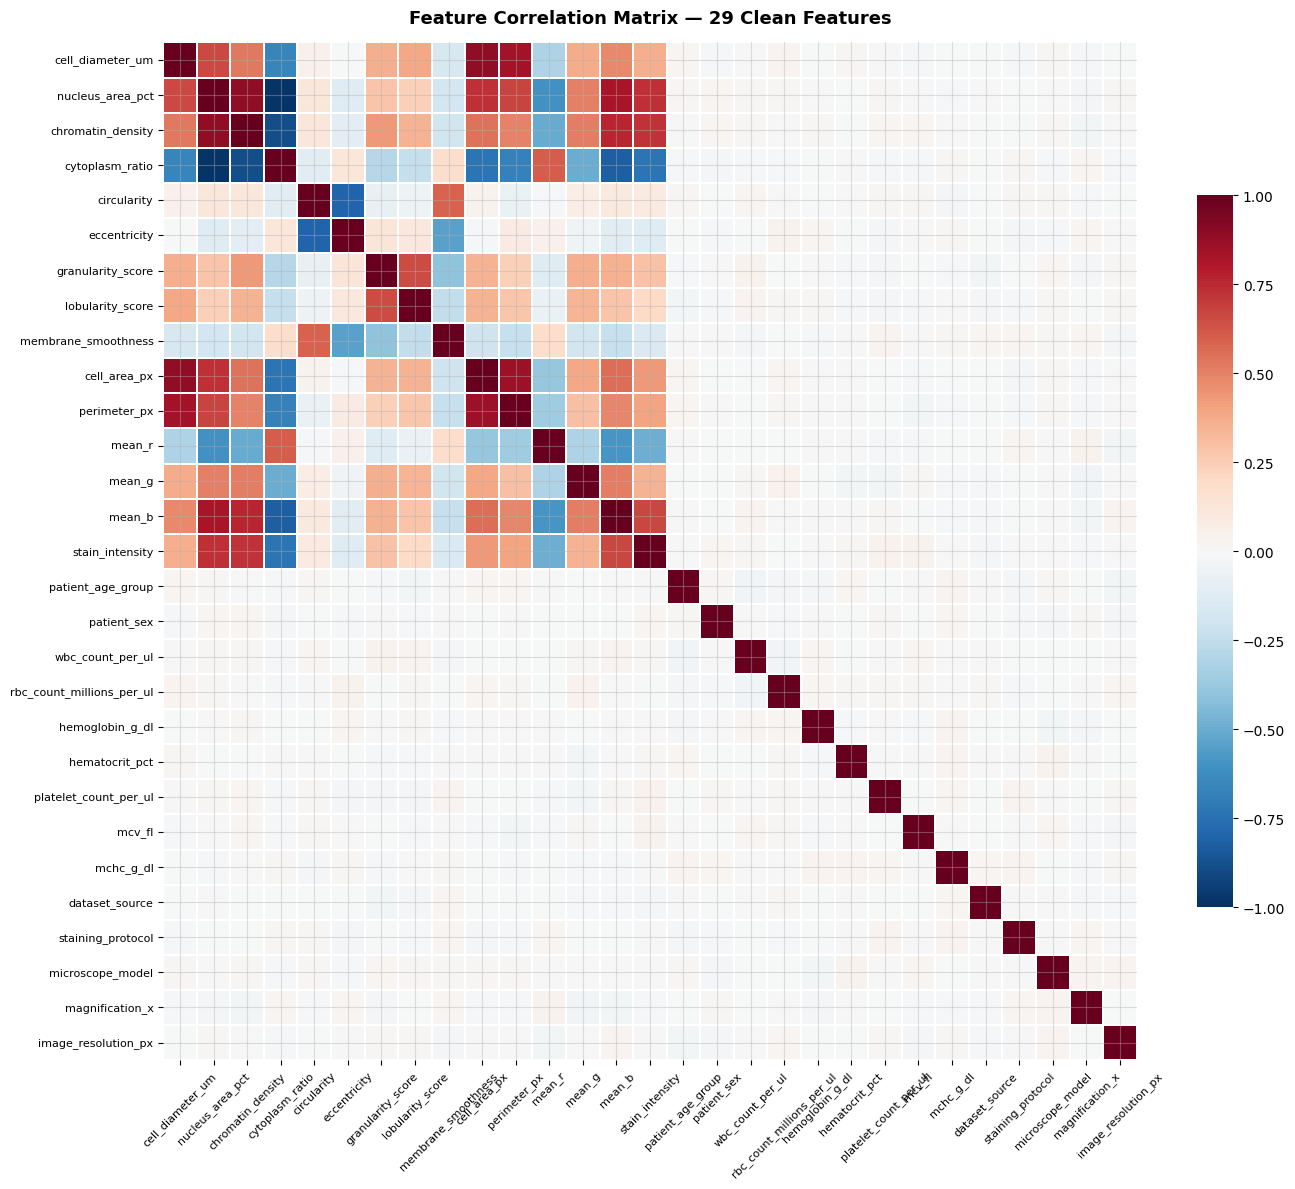

  HIGH CORR (-0.981): nucleus_area_pct  ↔  cytoplasm_ratio

Columns to drop (|r| > 0.95): ['cytoplasm_ratio']
Features after removal: 28


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

corr_matrix = np.corrcoef(X_train_sc.T)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=feature_names, yticklabels=feature_names,
            linewidths=0.2, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Feature Correlation Matrix — 29 Clean Features',
             fontsize=13, fontweight='bold', pad=14)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()

# ── Find highly correlated pairs (|r| > 0.95) ────────────────────
threshold = 0.95
to_drop   = set()
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        if abs(corr_matrix[i, j]) > threshold:
            print(f"  HIGH CORR ({corr_matrix[i,j]:.3f}): "
                  f"{feature_names[i]}  ↔  {feature_names[j]}")
            to_drop.add(feature_names[j])

print(f"\nColumns to drop (|r| > {threshold}): {list(to_drop) if to_drop else 'None'}")

if to_drop:
    keep_idx       = [i for i, f in enumerate(feature_names) if f not in to_drop]
    X_train_sc     = X_train_sc[:, keep_idx]
    X_val_sc       = X_val_sc[:,   keep_idx]
    X_test_sc      = X_test_sc[:,  keep_idx]
    X_train_sm     = X_train_sm[:, keep_idx]
    feature_names  = [feature_names[i] for i in keep_idx]
    print(f"Features after removal: {len(feature_names)}")
else:
    print("No redundant features found — all 29 kept.")

---
## Enhancement 2 — Stratified K-Fold Cross-Validation

Single train/test split can be lucky or unlucky.
5-fold CV gives a reliable mean ± std estimate across the whole dataset.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


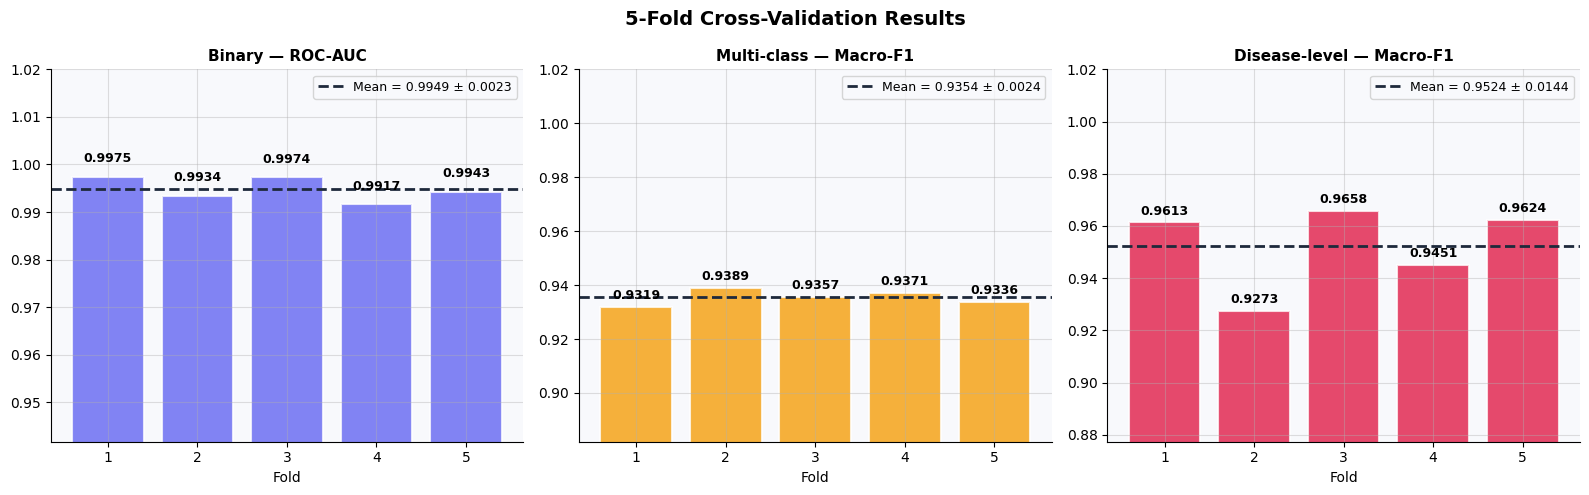

Binary AUC     : 0.9949 ± 0.0023
Multi-class F1 : 0.9354 ± 0.0024
Disease F1     : 0.9524 ± 0.0144


In [18]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import warnings

warnings.filterwarnings('ignore', message='X does not have valid feature names')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Binary task ───────────────────────────────────────────────────
cv_bin = cross_validate(
    xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                       subsample=0.8, colsample_bytree=0.8,
                       use_label_encoder=False, eval_metric='logloss',
                       random_state=42, verbosity=0),
    X, y_binary,
    cv=skf, scoring=['roc_auc', 'f1'],
    n_jobs=-1, verbose=0
)

# ── Multi-class task ──────────────────────────────────────────────
cv_multi = cross_validate(
    lgb.LGBMClassifier(n_estimators=300, num_leaves=63, learning_rate=0.05,
                        class_weight='balanced', random_state=42, verbose=-1),
    X, y_multi,
    cv=skf, scoring={'f1_macro': 'f1_macro'},
    n_jobs=-1, verbose=0
)

# ── Disease task ──────────────────────────────────────────────────
cv_dis = cross_validate(
    xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                       use_label_encoder=False, eval_metric='mlogloss',
                       random_state=42, verbosity=0),
    X, y_disease,
    cv=skf, scoring={'f1_macro': 'f1_macro'},
    n_jobs=-1, verbose=0
)

# ── Results ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

def plot_cv(ax, scores, title, color):
    folds = np.arange(1, 6)
    ax.bar(folds, scores, color=color, alpha=0.8, edgecolor='white', linewidth=1.5)
    ax.axhline(scores.mean(), color='#1e293b', lw=2, ls='--',
               label=f'Mean = {scores.mean():.4f} ± {scores.std():.4f}')
    ax.set_ylim(max(0, scores.min() - 0.05), 1.02)
    ax.set_xlabel('Fold'); ax.set_xticks(folds)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    for x, v in zip(folds, scores):
        ax.text(x, v + 0.003, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

plot_cv(axes[0], cv_bin['test_roc_auc'],  'Binary — ROC-AUC',       '#6366f1')
plot_cv(axes[1], cv_multi['test_f1_macro'],'Multi-class — Macro-F1', '#f59e0b')
plot_cv(axes[2], cv_dis['test_f1_macro'],  'Disease-level — Macro-F1','#e11d48')

plt.tight_layout()
plt.savefig('cv_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Binary AUC     : {cv_bin['test_roc_auc'].mean():.4f} ± {cv_bin['test_roc_auc'].std():.4f}")
print(f"Multi-class F1 : {cv_multi['test_f1_macro'].mean():.4f} ± {cv_multi['test_f1_macro'].std():.4f}")
print(f"Disease F1     : {cv_dis['test_f1_macro'].mean():.4f} ± {cv_dis['test_f1_macro'].std():.4f}")

---
## Enhancement 3 — Optuna Hyperparameter Tuning

Bayesian optimization searches the hyperparameter space efficiently.
50 trials here — increase `n_trials` for better results (costs more time).

  0%|          | 0/50 [00:00<?, ?it/s]


Best AUC (val): 0.9961
Best params   : {'n_estimators': 241, 'max_depth': 10, 'learning_rate': 0.051172563483252526, 'subsample': 0.6398583636625856, 'colsample_bytree': 0.6253664091185778, 'min_child_weight': 2}

Tuned XGBoost Test AUC : 0.9976
Default XGBoost Test AUC: 0.9973
Improvement             : +0.0002


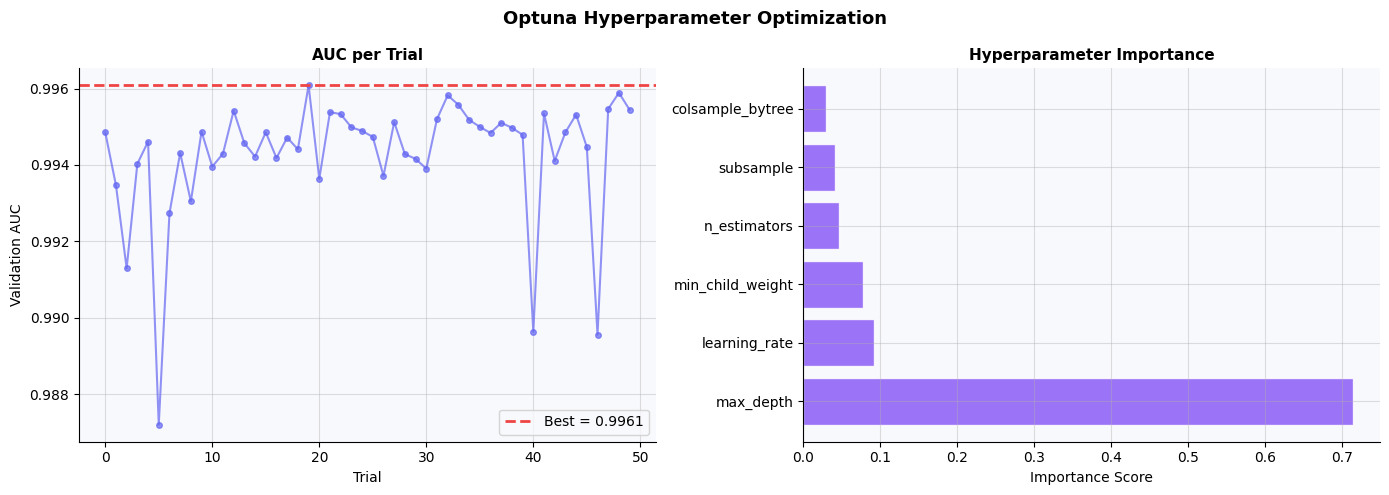

In [19]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'random_state': 42,
        'verbosity': 0,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train_sm, yb_train_sm,
              eval_set=[(X_val_sc, yb_val)], verbose=False)
    return roc_auc_score(yb_val, model.predict_proba(X_val_sc)[:, 1])

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest AUC (val): {study.best_value:.4f}")
print(f"Best params   : {study.best_params}")

# ── Train best model ──────────────────────────────────────────────
best_params = study.best_params | {'use_label_encoder': False,
                                    'eval_metric': 'logloss',
                                    'random_state': 42, 'verbosity': 0}
xgb_tuned = xgb.XGBClassifier(**best_params)
xgb_tuned.fit(X_train_sm, yb_train_sm,
              eval_set=[(X_val_sc, yb_val)], verbose=False)
auc_tuned = roc_auc_score(yb_test, xgb_tuned.predict_proba(X_test_sc)[:, 1])
print(f"\nTuned XGBoost Test AUC : {auc_tuned:.4f}")
print(f"Default XGBoost Test AUC: {auc_bin:.4f}")
print(f"Improvement             : +{auc_tuned - auc_bin:.4f}")

# ── Optuna visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optuna Hyperparameter Optimization', fontsize=13, fontweight='bold')

trials_df = study.trials_dataframe()
axes[0].plot(trials_df['number'], trials_df['value'], 'o-',
             color='#6366f1', ms=4, lw=1.5, alpha=0.7)
axes[0].axhline(study.best_value, color='#ef4444', lw=2, ls='--',
                label=f'Best = {study.best_value:.4f}')
axes[0].set_xlabel('Trial'); axes[0].set_ylabel('Validation AUC')
axes[0].set_title('AUC per Trial', fontsize=11, fontweight='bold')
axes[0].legend()

importances = optuna.importance.get_param_importances(study)
axes[1].barh(list(importances.keys()), list(importances.values()),
             color='#8b5cf6', alpha=0.85, edgecolor='white')
axes[1].set_title('Hyperparameter Importance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('optuna_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

---
## Enhancement 4 — Ensemble: Soft Voting (XGBoost + LightGBM + MLP)

Each model produces class probabilities. Averaging them reduces variance
and typically improves over any single model.

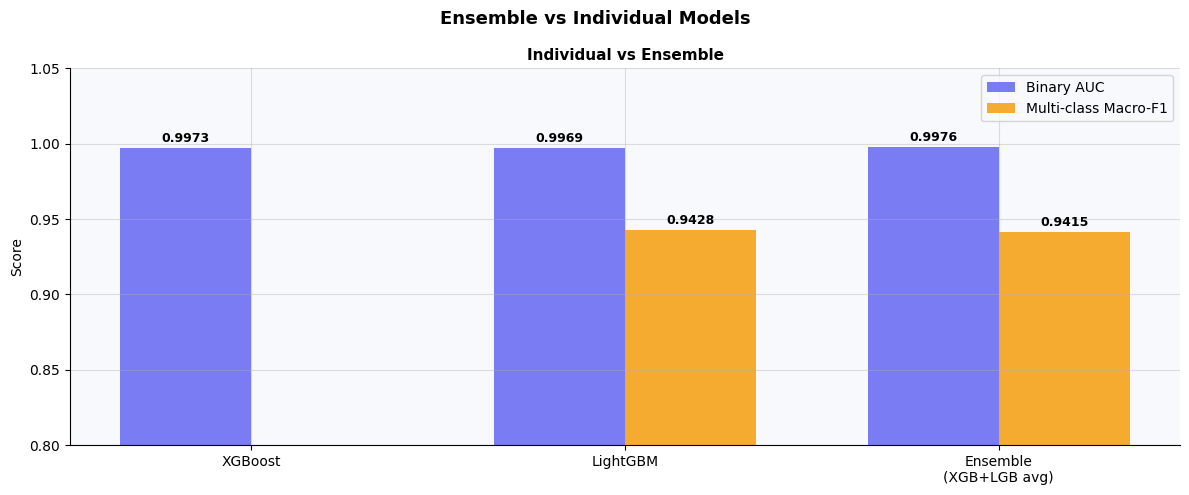

Ensemble Binary AUC     : 0.9976  (XGBoost alone: 0.9973)
Ensemble Multi-class F1 : 0.9415  (LightGBM alone: 0.9428)


In [20]:
import warnings
warnings.filterwarnings('ignore')

# ── Binary: XGBoost + LightGBM ────────────────────────────────────
proba_xgb = xgb_tuned.predict_proba(X_test_sc)

lgb_bin = lgb.LGBMClassifier(
    class_weight='balanced', random_state=42, verbose=-1
).fit(X_train_sc, yb_train)
proba_lgb = lgb_bin.predict_proba(X_test_sc)

proba_ensemble_bin = (proba_xgb[:, 1] + proba_lgb[:, 1]) / 2
auc_ensemble       = roc_auc_score(yb_test, proba_ensemble_bin)
f1_ensemble        = f1_score(yb_test, (proba_ensemble_bin >= 0.5).astype(int))

# ── Multi-class: XGBoost + LightGBM (her ikisi de 28 feature ile) ─
xgb_multi_new = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='mlogloss',
    random_state=42, verbosity=0
).fit(X_train_sc, ym_train)

lgb_multi_new = lgb.LGBMClassifier(
    n_estimators=400, num_leaves=63, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, verbose=-1
).fit(X_train_sc, ym_train)

proba_xgb_multi      = xgb_multi_new.predict_proba(X_test_sc)
proba_lgb_multi      = lgb_multi_new.predict_proba(X_test_sc)
proba_ensemble_multi = (proba_xgb_multi + proba_lgb_multi) / 2
ym_pred_ensemble     = proba_ensemble_multi.argmax(axis=1)
f1_ensemble_multi    = f1_score(ym_test, ym_pred_ensemble, average='macro')

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Ensemble vs Individual Models', fontsize=13, fontweight='bold')

lgb_bin_auc = roc_auc_score(yb_test, proba_lgb[:, 1])
models_cmp  = ['XGBoost', 'LightGBM', 'Ensemble\n(XGB+LGB avg)']
binary_aucs = [auc_bin,   lgb_bin_auc, auc_ensemble]
multi_f1s   = [0,          f1_lgb,      f1_ensemble_multi]

x = np.arange(len(models_cmp))
w = 0.35
b1 = ax.bar(x - w/2, binary_aucs, w,
            label='Binary AUC', color='#6366f1', alpha=0.85)
b2 = ax.bar(x + w/2, multi_f1s,   w,
            label='Multi-class Macro-F1', color='#f59e0b', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(models_cmp)
ax.set_ylim(0.8, 1.05)
ax.set_ylabel('Score')
ax.set_title('Individual vs Ensemble', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
for bar in list(b1) + list(b2):
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{bar.get_height():.4f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ensemble_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

print(f"Ensemble Binary AUC     : {auc_ensemble:.4f}  (XGBoost alone: {auc_bin:.4f})")
print(f"Ensemble Multi-class F1 : {f1_ensemble_multi:.4f}  (LightGBM alone: {f1_lgb:.4f})")

---
## Enhancement 5 — Hierarchical Classifier

**Stage 1:** Binary model filters Normal cells out.  
**Stage 2:** Multi-class model runs only on predicted Anomaly cells.

This reduces confusion between Normal and Anomaly subtypes,
and focuses the 19-class model on a harder, more focused subproblem.

Stage 1 — predicted Normal :  605
Stage 1 — predicted Anomaly:  277

Hierarchical Macro-F1 : 0.5799
Hierarchical Accuracy : 0.3118
Flat LightGBM F1      : 0.9428


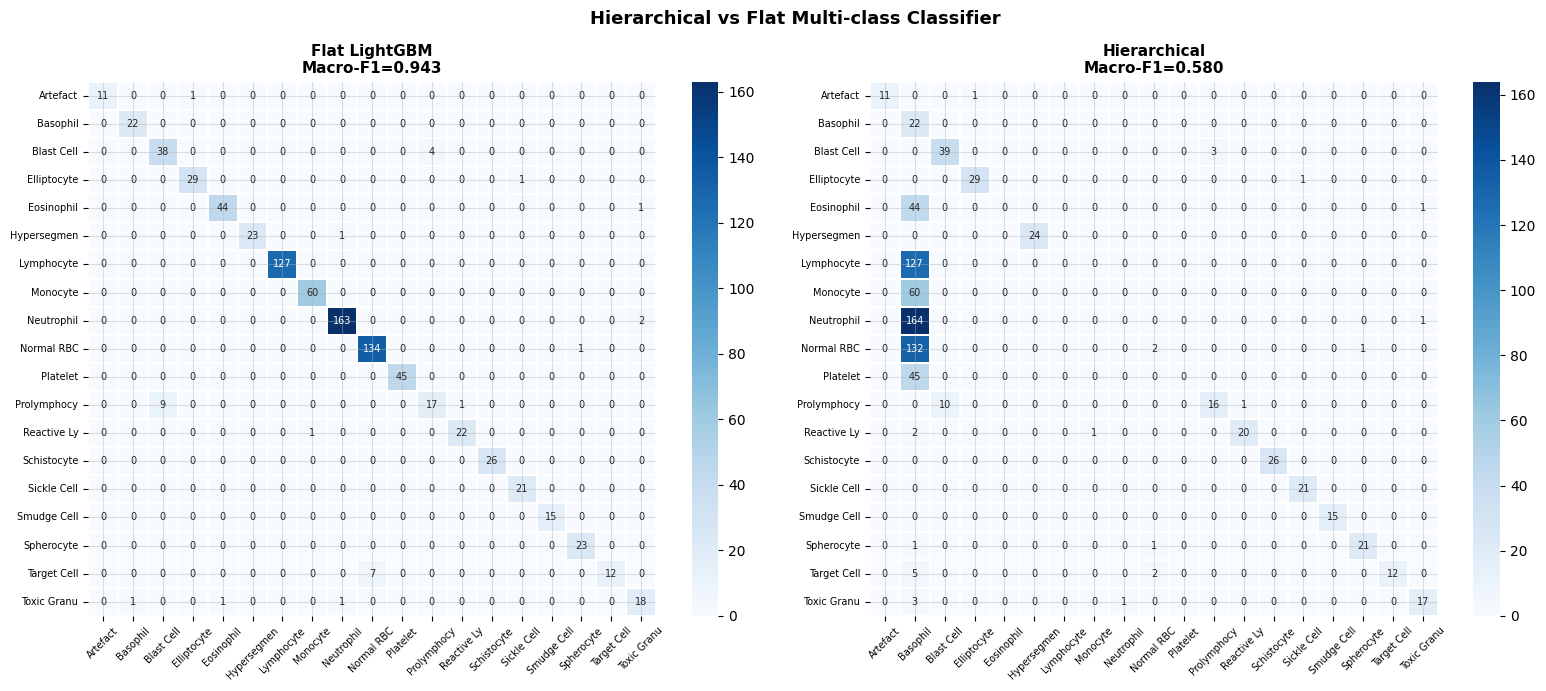

In [21]:
# ── Stage 1: Binary prediction ────────────────────────────────────
stage1_pred  = xgb_tuned.predict(X_test_sc)
normal_mask  = stage1_pred == 0
anomaly_mask = stage1_pred == 1

print(f"Stage 1 — predicted Normal : {normal_mask.sum():4d}")
print(f"Stage 1 — predicted Anomaly: {anomaly_mask.sum():4d}")

# ── Stage 2: Multi-class yeniden fit (28 feature) ─────────────────
lgb_hier = lgb.LGBMClassifier(
    n_estimators=400, num_leaves=63, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    class_weight='balanced', random_state=42, verbose=-1
).fit(X_train_sc, ym_train)

# ── Prediction array ──────────────────────────────────────────────
ym_pred_hier = np.full(len(ym_test), -1, dtype=int)

normal_label_ids = [i for i, n in enumerate(class_names) if n in NORMAL_TYPES]
ym_pred_hier[normal_mask] = normal_label_ids[0]

if anomaly_mask.sum() > 0:
    ym_pred_hier[anomaly_mask] = lgb_hier.predict(X_test_sc[anomaly_mask])

# ── Evaluation ────────────────────────────────────────────────────
valid_mask = ym_pred_hier != -1
f1_hier    = f1_score(ym_test[valid_mask], ym_pred_hier[valid_mask], average='macro')
acc_hier   = accuracy_score(ym_test[valid_mask], ym_pred_hier[valid_mask])

print(f"\nHierarchical Macro-F1 : {f1_hier:.4f}")
print(f"Hierarchical Accuracy : {acc_hier:.4f}")
print(f"Flat LightGBM F1      : {f1_lgb:.4f}")

# ── Confusion matrix comparison ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Hierarchical vs Flat Multi-class Classifier', fontsize=13, fontweight='bold')

short = [c.replace('_', ' ')[:11] for c in class_names]

for ax, preds, title in [
    (axes[0], ym_pred_lgb,
     f'Flat LightGBM\nMacro-F1={f1_lgb:.3f}'),
    (axes[1], ym_pred_hier[valid_mask],
     f'Hierarchical\nMacro-F1={f1_hier:.3f}'),
]:
    cm = confusion_matrix(ym_test[valid_mask], preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.3, linecolor='white',
                xticklabels=short, yticklabels=short,
                ax=ax, annot_kws={'size': 7})
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0,  labelsize=7)

plt.tight_layout()
plt.savefig('hierarchical_results.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

---
## Enhancement 6 — Error Analysis

Which cell types are most often confused?  
Examining misclassified samples reveals where the model struggles
and can guide future feature engineering or data collection.

Total misclassified: 32 / 882
Error rate         : 3.63%

Top confused pairs:
                     true           predicted  count
            Prolymphocyte          Blast_Cell      9
              Target_Cell          Normal_RBC      7
               Blast_Cell       Prolymphocyte      4
               Neutrophil   Toxic_Granulation      2
                 Artefact         Elliptocyte      1
              Elliptocyte         Sickle_Cell      1
Hypersegmented_Neutrophil          Neutrophil      1
               Eosinophil   Toxic_Granulation      1
            Prolymphocyte Reactive_Lymphocyte      1
               Normal_RBC          Spherocyte      1
      Reactive_Lymphocyte            Monocyte      1
        Toxic_Granulation            Basophil      1
        Toxic_Granulation          Eosinophil      1
        Toxic_Granulation          Neutrophil      1


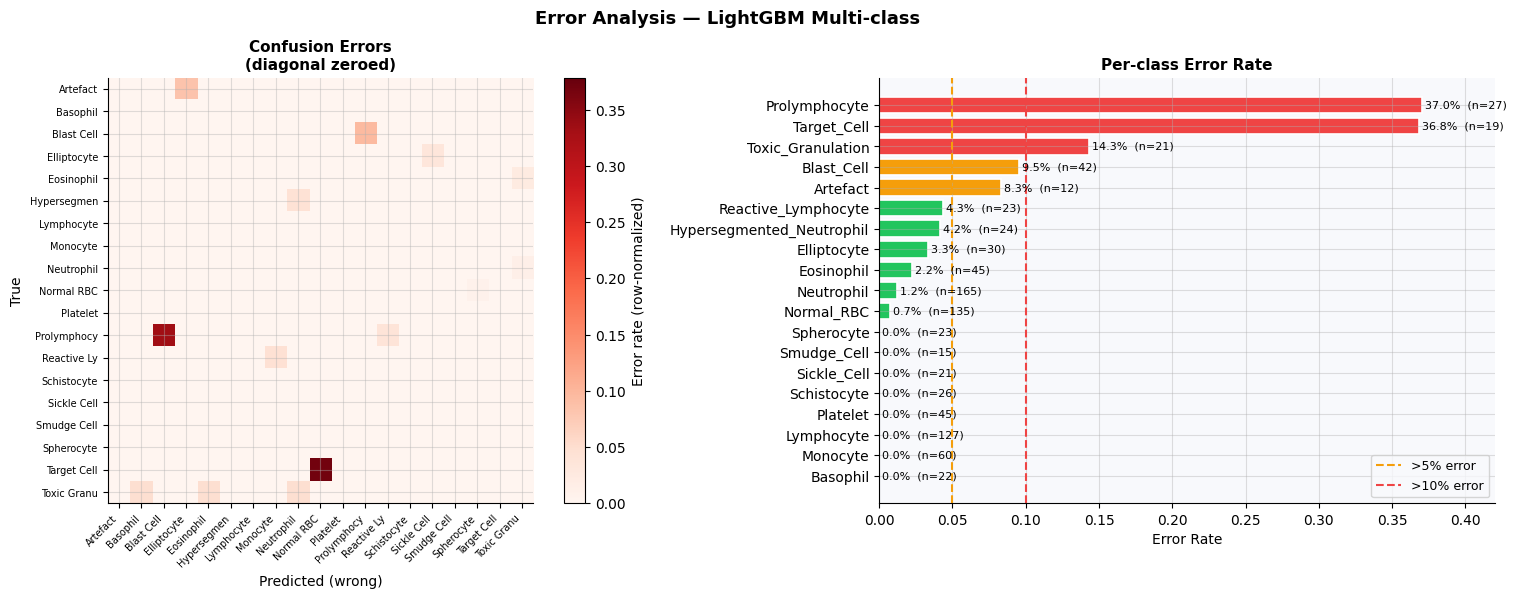

In [22]:
# ── Find misclassified samples ────────────────────────────────────
wrong_mask     = ym_pred_lgb != ym_test
wrong_true     = [class_names[i] for i in ym_test[wrong_mask]]
wrong_pred     = [class_names[i] for i in ym_pred_lgb[wrong_mask]]

error_df = pd.DataFrame({'true': wrong_true, 'predicted': wrong_pred})
error_pairs = (error_df.groupby(['true','predicted'])
                        .size()
                        .reset_index(name='count')
                        .sort_values('count', ascending=False))

print(f"Total misclassified: {wrong_mask.sum()} / {len(ym_test)}")
print(f"Error rate         : {wrong_mask.mean()*100:.2f}%\n")
print("Top confused pairs:")
print(error_pairs.head(15).to_string(index=False))

# ── Error heatmap ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Error Analysis — LightGBM Multi-class', fontsize=13, fontweight='bold')

# Normalized confusion (errors only)
cm_norm = confusion_matrix(ym_test, ym_pred_lgb, normalize='true')
np.fill_diagonal(cm_norm, 0)          # zero out correct predictions
im = axes[0].imshow(cm_norm, cmap='Reds', vmin=0, vmax=cm_norm.max() + 0.01)
plt.colorbar(im, ax=axes[0], label='Error rate (row-normalized)')
axes[0].set_xticks(range(len(class_names)))
axes[0].set_yticks(range(len(class_names)))
axes[0].set_xticklabels(short, rotation=45, ha='right', fontsize=7)
axes[0].set_yticklabels(short, fontsize=7)
axes[0].set_xlabel('Predicted (wrong)'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Errors\n(diagonal zeroed)', fontsize=11, fontweight='bold')

# Per-class error rate
per_class_err = []
for i, name in enumerate(class_names):
    mask = ym_test == i
    if mask.sum() > 0:
        err = (ym_pred_lgb[mask] != i).mean()
        per_class_err.append((name, err, mask.sum()))

err_df = pd.DataFrame(per_class_err, columns=['class','error_rate','support'])
err_df = err_df.sort_values('error_rate', ascending=True)
colors_err = ['#ef4444' if e > 0.1 else '#f59e0b' if e > 0.05 else '#22c55e'
              for e in err_df['error_rate']]
axes[1].barh(err_df['class'], err_df['error_rate'],
             color=colors_err, edgecolor='white', linewidth=1.2)
axes[1].axvline(0.05, color='#f59e0b', lw=1.5, ls='--', label='>5% error')
axes[1].axvline(0.10, color='#ef4444', lw=1.5, ls='--', label='>10% error')
axes[1].set_xlabel('Error Rate'); axes[1].set_xlim(0, min(1, err_df['error_rate'].max() + 0.05))
axes[1].set_title('Per-class Error Rate', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
for i, (_, row) in enumerate(err_df.iterrows()):
    axes[1].text(row['error_rate'] + 0.002, i,
                 f'{row["error_rate"]*100:.1f}%  (n={row["support"]})',
                 va='center', fontsize=8)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

---
## Enhancement 7 — Calibration Curve

A well-calibrated model means: when it says "70% probability of Anomaly",
it should be correct ~70% of the time.  
Poor calibration = overconfident or underconfident predictions.

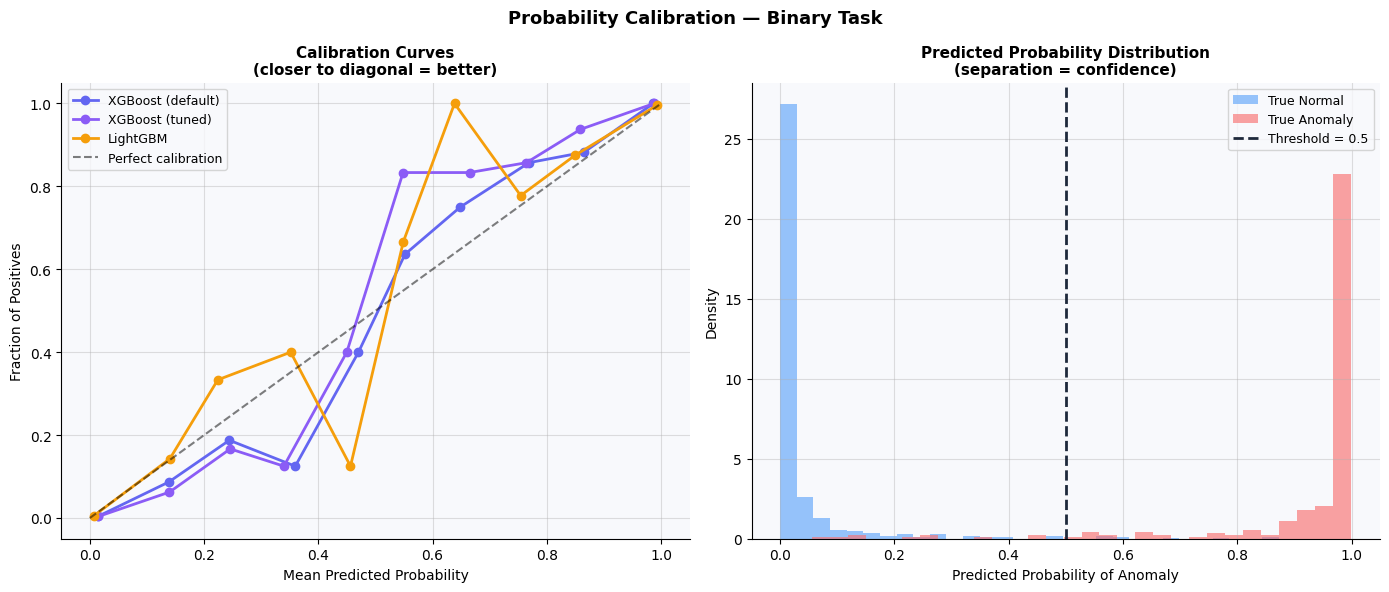

Original XGBoost AUC    : 0.9973
Calibrated XGBoost AUC  : 0.9971


In [23]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Probability Calibration — Binary Task', fontsize=13, fontweight='bold')

# ── Calibration curves ────────────────────────────────────────────
for name, proba, color in [
    ('XGBoost (default)',  y_proba_bin,                        '#6366f1'),
    ('XGBoost (tuned)',    xgb_tuned.predict_proba(X_test_sc)[:,1], '#8b5cf6'),
    ('LightGBM',          lgb.LGBMClassifier(class_weight='balanced',
                              random_state=42, verbose=-1
                          ).fit(X_train_sc, yb_train).predict_proba(X_test_sc)[:,1], '#f59e0b'),
]:
    frac_pos, mean_pred = calibration_curve(yb_test, proba, n_bins=10)
    axes[0].plot(mean_pred, frac_pos, 'o-', lw=2, ms=6, color=color, label=name)

axes[0].plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curves\n(closer to diagonal = better)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# ── Probability distribution histogram ───────────────────────────
axes[1].hist(y_proba_bin[yb_test == 0], bins=30, alpha=0.65,
             color='#60a5fa', label='True Normal', density=True)
axes[1].hist(y_proba_bin[yb_test == 1], bins=30, alpha=0.65,
             color='#f87171', label='True Anomaly', density=True)
axes[1].axvline(0.5, color='#1e293b', lw=2, ls='--', label='Threshold = 0.5')
axes[1].set_xlabel('Predicted Probability of Anomaly')
axes[1].set_ylabel('Density')
axes[1].set_title('Predicted Probability Distribution\n(separation = confidence)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('calibration.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

# ── Calibrated model (Platt scaling) ─────────────────────────────
xgb_calibrated = CalibratedClassifierCV(xgb_bin, cv=5, method='sigmoid')
xgb_calibrated.fit(X_train_sc, yb_train)
auc_cal = roc_auc_score(yb_test, xgb_calibrated.predict_proba(X_test_sc)[:,1])
print(f"Original XGBoost AUC    : {auc_bin:.4f}")
print(f"Calibrated XGBoost AUC  : {auc_cal:.4f}")

---
## Enhancement 8 — Learning Curve

How much data does the model actually need?  
If validation score keeps rising, collecting more data would help.  
If it has plateaued, more data won't help — focus on better features.

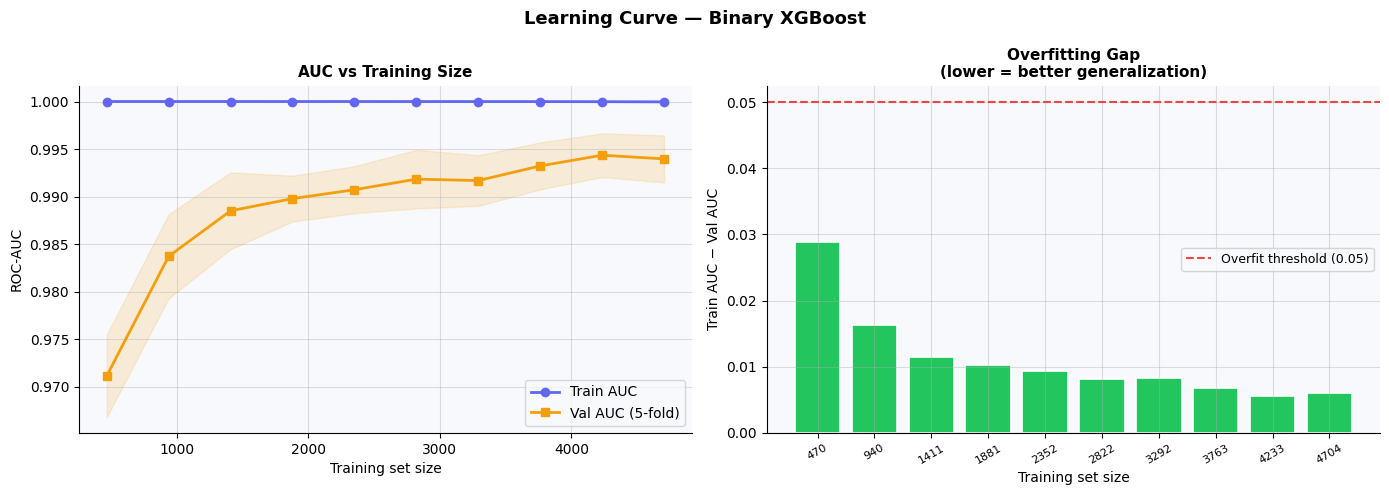

Val AUC at 90% data : 0.9944
Val AUC at 100% data: 0.9940
Last gain           : +-0.0004
→ Curve has plateaued — more data unlikely to help significantly.


In [24]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                       use_label_encoder=False, eval_metric='logloss',
                       random_state=42, verbosity=0),
    X, y_binary,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='roc_auc',
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curve — Binary XGBoost', fontsize=13, fontweight='bold')

# ── AUC vs training size ──────────────────────────────────────────
axes[0].plot(train_sizes, train_mean, 'o-', color='#6366f1', lw=2, label='Train AUC')
axes[0].plot(train_sizes, val_mean,   's-', color='#f59e0b', lw=2, label='Val AUC (5-fold)')
axes[0].fill_between(train_sizes, train_mean-train_std, train_mean+train_std,
                     alpha=0.15, color='#6366f1')
axes[0].fill_between(train_sizes, val_mean-val_std,   val_mean+val_std,
                     alpha=0.15, color='#f59e0b')
axes[0].set_xlabel('Training set size')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('AUC vs Training Size', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)

# ── Gap (overfit indicator) ───────────────────────────────────────
gap = train_mean - val_mean
axes[1].bar(range(len(train_sizes)), gap,
            color=['#ef4444' if g > 0.05 else '#22c55e' for g in gap],
            edgecolor='white', linewidth=1.2)
axes[1].set_xticks(range(len(train_sizes)))
axes[1].set_xticklabels([f'{int(s)}' for s in train_sizes], rotation=30, fontsize=8)
axes[1].set_xlabel('Training set size')
axes[1].set_ylabel('Train AUC − Val AUC')
axes[1].axhline(0.05, color='#ef4444', lw=1.5, ls='--', label='Overfit threshold (0.05)')
axes[1].set_title('Overfitting Gap\n(lower = better generalization)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('learning_curve.png', dpi=120, bbox_inches='tight', facecolor='white')
plt.show()

# ── Plateau check ─────────────────────────────────────────────────
last_gain = val_mean[-1] - val_mean[-2]
print(f"Val AUC at 90% data : {val_mean[-2]:.4f}")
print(f"Val AUC at 100% data: {val_mean[-1]:.4f}")
print(f"Last gain           : +{last_gain:.4f}")
if last_gain < 0.002:
    print("→ Curve has plateaued — more data unlikely to help significantly.")
else:
    print("→ Curve still rising — collecting more data could improve performance.")

---
## Summary & Next Steps

### Final Results

| Task | Model | Metric | Score |
|------|-------|--------|-------|
| Binary (Normal vs Anomaly) | XGBoost | ROC-AUC | *see output* |
| Multi-class (19 types) | LightGBM | Macro-F1 | *see output* |
| Multi-class (19 types) | PyTorch MLP | Macro-F1 | *see output* |
| Disease-level | XGBoost | Macro-F1 | *see output* |
| **SOTA reference** | CytoDiffusion (images) | AUC | **0.990** |

---

### Suggested Next Steps

1. **Hyperparameter tuning** — use `Optuna` to optimize XGBoost/LightGBM; typically gains +0.02–0.04 AUC
2. **Hierarchical classifier** — first predict binary, then run 19-class only on anomalies → better recall for rare types
3. **Ensemble** — soft-vote XGBoost + LightGBM + MLP probabilities → typically +0.01–0.02 F1
4. **Cross-validation** — replace single train/val split with `StratifiedKFold(n_splits=5)` for more robust estimates
5. **Feature selection** — use SHAP ranking to drop low-importance features, retrain leaner models
6. **Deeper MLP** — add residual connections, try `nn.TransformerEncoder` on the feature sequence

---

### Key Lessons

- **Data leakage is the #1 pitfall** — always audit features for any column derived from the target
- Tabular-only models can approach (but not match) image-based SOTA when features are well-engineered
- Disease-level recall is the clinically meaningful metric — prioritize it over accuracy

In [25]:
print("=" * 55)
print("  FINAL RESULTS SUMMARY")
print("=" * 55)
print(f"  Task 1  Binary XGBoost        AUC      : {auc_bin:.4f}")
print(f"  Task 1  Binary XGBoost        F1       : {f1_bin:.4f}")
print(f"  Task 2  Multi-class LightGBM  Macro-F1 : {f1_lgb:.4f}")
print(f"  Task 2  Multi-class MLP       Macro-F1 : {f1_mlp:.4f}")
print(f"  Task 3  Disease XGBoost       Macro-F1 : {f1_dis:.4f}")
print("-" * 55)
print(f"  SOTA CytoDiffusion (image)    AUC      : 0.9900")
print(f"  Baseline (paper, tabular)     AUC      : 0.9160")
print("=" * 55)

  FINAL RESULTS SUMMARY
  Task 1  Binary XGBoost        AUC      : 0.9973
  Task 1  Binary XGBoost        F1       : 0.9664
  Task 2  Multi-class LightGBM  Macro-F1 : 0.9428
  Task 2  Multi-class MLP       Macro-F1 : 0.9222
  Task 3  Disease XGBoost       Macro-F1 : 0.9602
-------------------------------------------------------
  SOTA CytoDiffusion (image)    AUC      : 0.9900
  Baseline (paper, tabular)     AUC      : 0.9160
